In [ ]:
# Install and upgrade libraries
!pip install --upgrade gensim nltk pyLDAvis preprocessor rake-nltk emoji

# Restart runtime
import os
os.kill(os.getpid(), 9)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.8 MB/s eta 0:00:00
  Created wheel for preprocessor: filename=preprocessor-1.1.3-py3-none-any.whl size=4474 sha256=aca73381aecf844b59d306b420089c0ff7fbec5c7628e29e2a1d2fb7b89bb4d4
  Stored in directory: /root/.cache/pip/wheels/60/33/31/972a156cd609581707e69298b91f0e42d349c08fefc173e19e
Successfully built preprocessor
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


#Library

In [ ]:
# After restart, run this cell and the rest of your code
import os
import warnings

import pandas as pd
import numpy as np
import io

import tweepy
import csv
import preprocessor as p

import string
import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from wordcloud import WordCloud

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from nltk import pos_tag, word_tokenize

from pprint import pprint
import spacy

import gensim
import gensim.corpora as corpora
from gensim.models.phrases import Phrases, Phraser
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from gensim.models import LdaMulticore,Word2Vec, FastText, CoherenceModel, LdaModel

import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.distance import cosine

from matplotlib import pyplot as plt
import plotly.graph_objects as go

import pickle
from tqdm import tqdm

import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from rake_nltk import Rake


import umap
from umap import UMAP
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

import nltk
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.sentiment import SentimentIntensityAnalyzer
import emoji
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import plotly.express as px

os.environ["PYTHONWARNINGS"] = "ignore::DeprecationWarning"
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
nltk.download('punkt')  # For tokenization
nltk.download('stopwords')  # For stop words
nltk.download('wordnet')  # For lemmatization
nltk.download('punkt_tab') # for other languages tokenization
nltk.download('averaged_perceptron_tagger_eng') # Download the specific resource needed

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

#Usher Comments

In [ ]:
# Load the CSV file with specified encoding and low_memory=False to avoid DtypeWarning
df = pd.read_csv('/content/drive/MyDrive/Data/SBHT/usher_comments.csv')

# Select the 'title' column for LDA Topic modeling
text = df['text']

# Drop rows with NaN values in the 'Title' column
text = text.dropna()

print(text)

0                                      USHER IS A LEGEND 🔥
1                                                    Yeah!
2                                           Let Him Cook!!
3                                    Ok so I ate a raccoon
4        All these star performers came together tonigh...
                               ...                        
36762                         Fireeeee asfff usher Ateeee😭
36763                                                first
36764                                          yuppp usher
36765                                          Legendary 🔥
36766                                              Usher??
Name: text, Length: 36757, dtype: object


##Preprocessing

In [ ]:
!pip install langid
import re
import pandas as pd
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from gensim.models import Phrases
from gensim.models.phrases import Phraser
import langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=7ff257dea692017e986ab7dca0bcb96292c394f15acb22818ace92a0492ed680
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
nlp = spacy.load('en_core_web_sm')

# Initialize TweetTokenizer for better handling of YouTube Title text
tokenizer = word_tokenize

# Create a set of stopwords including contraction keys and their expansions
nltk_stopwords = set(stopwords.words('english'))
YT_comment_stopwords = { }  # Common YouTube title-specific words
custom_stopwords = {
    # Existing pronouns and contractions
    "weve", "im", "whos", "hes", "whats", "they", "us", "the", "a", "an", "is", "are", "was", "were",
    "you", "we", "i", "what", "who", "youll", "your", "youre", "youd", "theyre", "be", "do",
    "would", "could", "should", "will",

    # Additional pronouns and related terms from tokenized list
    "that", "not", "cannot", "havenot", "willnot", "wouldnot", "either", "else",
    "anyone", "anybody", "everyone", "every", "other", "can",

    # Conversational fillers from tokenized list (common in social media discussions)
    "lol", "lmao", "haha", "hahaha", "wtf", "yeah", "yep", "yea", "yah", "hey", "whoop",
    "wow", "oops", "ummm", "ffs", "cmon", "lmaooo", "wth", "geez", "jeez",

    # Vague or generic terms from tokenized list
    "thing", "something", "anything", "everything", "stuff", "kind", "sort", "type",
    "nothing", "somewhat", "maybe", "perhaps", "anyway", "anymore",

    # High-frequency verbs and modifiers from tokenized list
    "get", "know", "think", "say", "seem", "seems", "look", "like", "want", "make",
    "take", "come", "try", "use", "sure", "really", "pretty", "actually", "basically",
    "totally", "absolutely", "probably", "definitely", "exactly", "always", "never",
    "still", "already", "yet", "almost", "sometimes",

}
# Combine all stopwords
all_stopwords = nltk_stopwords.union(YT_comment_stopwords).union(custom_stopwords)

In [ ]:
# -------------------------------
# Language detection helper
# -------------------------------
def is_english(text, min_len=10, threshold=0.90):
    """
    Return True if `text` is confidently English.
    - Skips very short strings (min_len) to avoid garbage classification.
    - Uses langid to classify and requires prob >= threshold.
    """
    if not isinstance(text, str):
        return False
    stripped = text.strip()
    if len(stripped) < min_len:
        return False
    lang, prob = langid.classify(stripped)
    return (lang == "en") and (prob >= threshold)

# -------------------------------
# POS mapping helper
# -------------------------------
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default to noun

# -------------------------------
# Preprocessing function (English text assumed)
# -------------------------------
def preprocess_youtube_comment(text):
    if pd.isna(text):
        return []

    # normalize + clean
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                    # @mentions
    text = re.sub(r'#\w+', '', text)                    # hashtags (strip entirely)
    text = re.sub(r'[^\w\s]', '', text)                 # punctuation
    text = re.sub(r'\b(ep|episode)\s?\d+\b', '', text)  # ep/episode numbers
    text = re.sub(r'\d+/\d+/\d+', '', text)             # dates like 10/24/2025
    text = re.sub(r'\d+', '', text)                     # all numbers

    # tokenize + stopword filter
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in all_stopwords]

    # POS tag + lemmatize, keep only alpha tokens len>=3
    tokens_pos = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in tokens_pos
        if word.strip() != "" and len(word) > 2 and word.isalpha()
    ]

    return lemmatized_tokens

# -------------------------------
# Process your pandas Series of comments
# -------------------------------
# Assume `text` is your input Series
text = text.drop_duplicates(keep='first').reset_index(drop=True)
processed_comments = text.apply(preprocess_youtube_comment)
processed_comments = processed_comments[processed_comments.map(lambda x: len(x) > 0)].reset_index(drop=True)

# -------------------------------
# Apply Bigram modeling
# -------------------------------
bigram = Phrases(processed_comments, min_count=5, threshold=10)
bigram_mod = Phraser(bigram)
processed_comments = processed_comments.apply(lambda x: bigram_mod[x])

# Final output
data_ready = processed_comments
print(data_ready)

0                                          [usher, legend]
1                                              [let, cook]
2                                           [ate, raccoon]
3        [star, performer, come, together, tonight, mak...
4                                    [click, link, werido]
                               ...                        
33156          [fart, hobby, mine, ngl, good, show, usher]
33157                                    [love, bit, show]
33158                     [fireeeee, asfff, usher, ateeee]
33159                                       [yuppp, usher]
33160                                              [usher]
Name: text, Length: 33161, dtype: object


##EDA (Exploratory Data Analysis)

In [ ]:
# Get all unique words across all tokenized titles
# Filter out NaN values before iterating
all_words = [word for text_tokens in data_ready.dropna() for word in text_tokens]

# Create a set of unique words
unique_words = set(all_words)

print("Total documents:", len(data_ready))
print("Average document length:", np.mean([len(doc) for doc in data_ready.dropna()])) # Also filter for average length
print("Unique words:", len(unique_words))

Total documents: 33161
Average document length: 5.499864298422846
Unique words: 19616


[('usher', 7929), ('performance', 3500), ('show', 2961), ('love', 2511), ('best', 1615), ('good', 1571), ('great', 1569), ('halftime_show', 1525), ('one', 1440), ('time', 1421), ('song', 1218), ('watch', 1130), ('super_bowl', 1042), ('see', 1034), ('well', 1008), ('amaze', 951), ('legend', 949), ('get', 936), ('ever', 876), ('music', 831), ('dance', 831), ('didnt', 797), ('man', 758), ('alicia_key', 747), ('bad', 703), ('superbowl', 686), ('dont', 677), ('live', 650), ('much', 641), ('year', 629)]


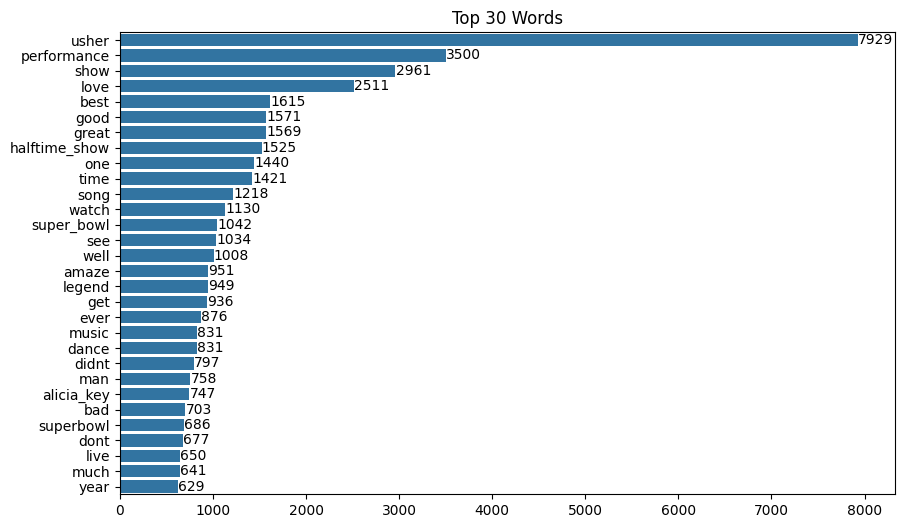

Top Bigrams: [(('of', 'the'), 1202), (('the', 'best'), 968), (('in', 'the'), 830), (('Usher', 'is'), 797), (('halftime', 'show'), 721), (('I', 'was'), 635), (('This', 'was'), 634), (('it', 'was'), 619), (('half', 'time'), 586), (('Super', 'Bowl'), 585), (('is', 'a'), 578), (('was', 'a'), 539), (('to', 'the'), 509), (('I', 'love'), 503), (('one', 'of'), 491), (('is', 'the'), 484), (('at', 'the'), 472), (('This', 'is'), 445), (('Alicia', 'Keys'), 420), (('to', 'be'), 403)]


In [ ]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
import seaborn as sns

# Word Frequency
# Flatten the list of lists into a single list of words
all_words = [word for text_tokens in data_ready.dropna() for word in text_tokens]

word_freq = Counter(all_words)  # Count word frequencies
top_words = word_freq.most_common(30)
print(top_words)

# Plot Top Words
words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(counts), y=list(words))  # Store the Axes object
plt.title("Top 30 Words")

# Add word counts as text annotations
for p in ax.patches:  # Iterate through the bars (patches)
    width = p.get_width()  # Get the width of the bar
    ax.text(width + 1,       # Position the text slightly to the right of the bar
            p.get_y() + p.get_height() / 2,  # Vertically center the text within the bar
            '{:1.0f}'.format(width),  # Format the count (remove decimal part)
            ha="left", va="center")  # Align the text

plt.show()

# Bigrams
# Assuming 'text' is your original Series of titles before tokenization
bigrams = Counter(ngrams(text.str.cat(sep=' ').split(), 2)).most_common(20)
print("Top Bigrams:", bigrams)

##LDA Topic Modeling

In [ ]:
#Creating a Bag Of Words
from gensim.corpora import Dictionary
import pyLDAvis
pyLDAvis.enable_notebook()

# Assuming 'documents' is a list of tokenized documents
# Filter out NaN values before creating the dictionary and corpus
filtered_data_ready = data_ready.dropna()
text_dict = Dictionary(filtered_data_ready)
corpus = [text_dict.doc2bow(doc) for doc in filtered_data_ready]

#view integer mappings
text_dict.token2id

{'legend': 0,
 'usher': 1,
 'cook': 2,
 'let': 3,
 'ate': 4,
 'raccoon': 5,
 'come': 6,
 'make_sense': 7,
 'maroon': 8,
 'others': 9,
 'performer': 10,
 'star': 11,
 'together': 12,
 'tonight': 13,
 'unlike': 14,
 'year_ago': 15,
 'click': 16,
 'link': 17,
 'werido': 18,
 'watch': 19,
 'bad': 20,
 'glad': 21,
 'halftime_show': 22,
 'miss': 23,
 'show': 24,
 'justin_bieber': 25,
 'need': 26,
 'google': 27,
 'lie': 28,
 'wont': 29,
 'coverage': 30,
 'excellent': 31,
 'topic': 32,
 'atlanta': 33,
 'dallas': 34,
 'problem': 35,
 'whatever': 36,
 'effort': 37,
 'put': 38,
 'espectacular': 39,
 'best': 40,
 'ive_see': 41,
 'superbowl': 42,
 'get_bad': 43,
 'move': 44,
 'shock': 45,
 'tht': 46,
 'try': 47,
 'lot': 48,
 'кортизола': 49,
 'много': 50,
 'оставлено': 51,
 'bad_bunny': 52,
 'artista': 53,
 'los_mejores': 54,
 'ofrecido': 55,
 'que': 56,
 'favorite_part': 57,
 'love': 58,
 'man': 59,
 'friend': 60,
 'share': 61,
 'audience': 62,
 'comment': 63,
 'highlight': 64,
 'loyalty': 65,
 's

In [ ]:
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Function to compute coherence values for different numbers of topics
def compute_coherence_values(corpus, dictionary, k_min, k_max, step=1):
    coherence_values = []
    topic_nums = list(range(k_min, k_max + 1, step))

    # Filter out NaN values before using as texts for CoherenceModel
    filtered_data = tokenized_series.dropna()

    for num_topics in topic_nums:
        lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, random_state=42)
        coherence_model_lda = CoherenceModel(model=lda_model, texts=filtered_data, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model_lda.get_coherence())

    return topic_nums, coherence_values

In [ ]:
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Function to compute coherence values for different numbers of topics
def compute_coherence_values(corpus, dictionary, k_min, k_max, step=1):
    coherence_values = []
    topic_nums = list(range(k_min, k_max + 1, step))

    # Filter out NaN values before using as texts for CoherenceModel
    filtered_data = data_ready.dropna()

    for num_topics in topic_nums:
        lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, random_state=42)
        coherence_model_lda = CoherenceModel(model=lda_model, texts=filtered_data, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model_lda.get_coherence())

    return topic_nums, coherence_values

In [ ]:
# Determine the optimal number of topics
k_min, k_max, step = 2, 15, 1
topic_nums, coherence_values = compute_coherence_values(corpus, text_dict, k_min, k_max, step)

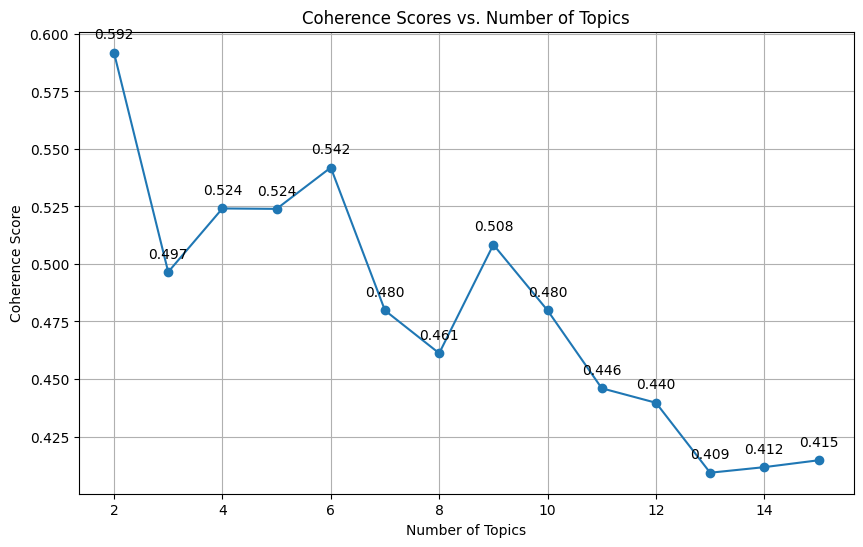

Optimal number of topics: 2


In [ ]:
# Plot coherence score
plt.figure(figsize=(10, 6))
plt.plot(topic_nums, coherence_values, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Scores vs. Number of Topics")
plt.grid()

# Annotate each point with its coherence score
for i, txt in enumerate(coherence_values):
    plt.annotate(f"{txt:.3f}", (topic_nums[i], coherence_values[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

optimal_num_topics = topic_nums[np.argmax(coherence_values)]
print(f"Optimal number of topics: {optimal_num_topics}")

##Stability and Perplexity Score

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [ ]:
# Prepare data for topic modeling (Scikit-Learn expects strings)
data_ready_sklearn = [' '.join(tokens) for tokens in data_ready]  # Join tokens for Scikit-Learn

# Step 1: Build Scikit-Learn LDA Model with 3 Topics
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
data_vectorized = vectorizer.fit_transform(data_ready_sklearn)

lda_sklearn = LatentDirichletAllocation(n_components=4, learning_decay=0.5, random_state=42)
lda_sklearn.fit(data_vectorized)

LatentDirichletAllocation(learning_decay=0.5, n_components=4, random_state=42)

###Stability Score

Stability for 2 topics: 0.6458169221511065
Stability for 3 topics: 0.5087849170204541
Stability for 4 topics: 0.46141226019117915
Stability for 5 topics: 0.43638781624509937
Stability for 6 topics: 0.39691625045200124
Stability for 7 topics: 0.37812284134647467
Stability for 8 topics: 0.33610610939669505
Stability for 9 topics: 0.3093852830274252
Stability for 10 topics: 0.2823220661918206
Stability for 11 topics: 0.2699266496828393
Stability for 12 topics: 0.2476764495379693
Stability for 13 topics: 0.23051613372607616
Stability for 14 topics: 0.22229746479657814
Stability for 15 topics: 0.21214468659370578
Stability score for the optimal number of topics (6): 0.39691625045200124


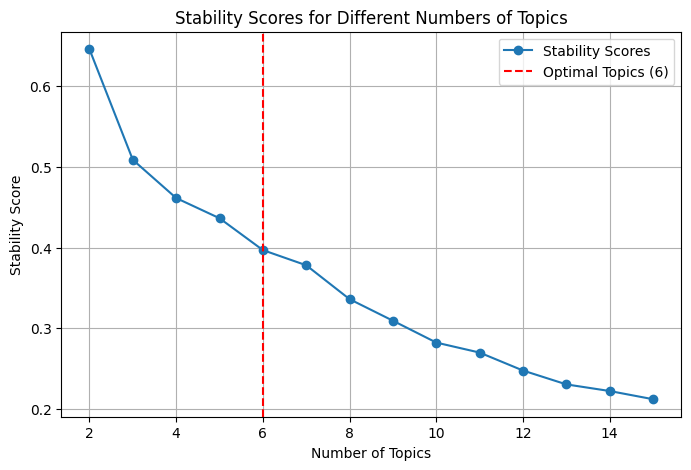

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

# Function to calculate stability score for a given number of topics
def calculate_stability(n_components, data, n_runs=5, random_states=range(5)):
    topic_distributions = []
    for seed in random_states:
        lda_temp = LatentDirichletAllocation(n_components=n_components, random_state=seed)
        lda_temp.fit(data)
        topic_distributions.append(lda_temp.components_)

    # Compute pairwise cosine similarities between consecutive topic matrices
    pairwise_similarities = [
        cosine_similarity(a, b).mean()
        for a, b in zip(topic_distributions[:-1], topic_distributions[1:])
    ]
    # Return average stability score
    return np.mean(pairwise_similarities)

# Range of topics to evaluate (focused around the optimal number)
topic_range = range(2, 16)  # From 2 to 15 topics
stability_scores = []

# Calculate stability for each number of topics
for n_topics in topic_range:
    score = calculate_stability(n_components=n_topics, data=data_vectorized)
    stability_scores.append(score)
    print(f"Stability for {n_topics} topics: {score}")

# Specific stability for the optimal number of topics (11)
optimal_topics = 6
optimal_score = calculate_stability(n_components=optimal_topics, data=data_vectorized)
print(f"Stability score for the optimal number of topics ({optimal_topics}): {optimal_score}")

# Plot stability scores
plt.figure(figsize=(8, 5))
plt.plot(topic_range, stability_scores, marker='o', linestyle='-', label="Stability Scores")
plt.axvline(x=optimal_topics, color='red', linestyle='--', label=f"Optimal Topics ({optimal_topics})")
plt.title("Stability Scores for Different Numbers of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Stability Score")
plt.grid(True)
plt.legend()
plt.show()

###Perplexity Score

Topics: 2, Perplexity: 3.694833048144749
Topics: 3, Perplexity: 5.500819500532075
Topics: 4, Perplexity: 7.302639630440579
Topics: 5, Perplexity: 9.055226494982604
Topics: 6, Perplexity: 10.776866518046404
Topics: 7, Perplexity: 14.410422407303049
Topics: 8, Perplexity: 16.42397227085464
Topics: 9, Perplexity: 15.874373293180772
Topics: 10, Perplexity: 17.56555256767414
Topics: 11, Perplexity: 19.255044898859772
Topics: 12, Perplexity: 24.4487222734865
Topics: 13, Perplexity: 26.452316068568322
Topics: 14, Perplexity: 28.455423155290127
Topics: 15, Perplexity: 26.00328394055438
Optimal Number of Topics: 6, Perplexity: 10.776866518046404


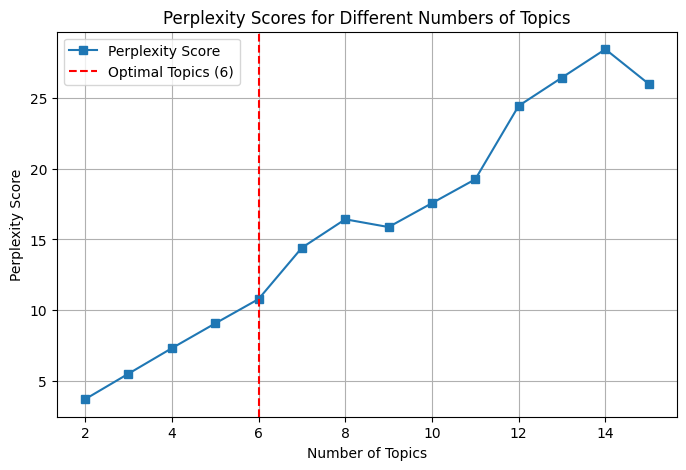

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Example data
data_ready_sklearn = ["sample text data", "another sample text", "more text data for LDA"]

# Vectorize data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
data_vectorized = vectorizer.fit_transform(data_ready_sklearn)

# Function to calculate perplexity score
def calculate_perplexity(n_components, data):
    lda_temp = LatentDirichletAllocation(n_components=n_components, random_state=42)
    lda_temp.fit(data)
    return lda_temp.perplexity(data)

# Range of topics to evaluate (focused around the optimal number)
topic_range = range(2, 16)  # From 2 to 15 topics
perplexity_scores = []

# Calculate perplexity for each number of topics
for n_topics in topic_range:
    perplexity_score = calculate_perplexity(n_components=n_topics, data=data_vectorized)
    perplexity_scores.append(perplexity_score)
    print(f"Topics: {n_topics}, Perplexity: {perplexity_score}")

# Specific perplexity for the optimal number of topics
optimal_topics = 6
optimal_perplexity = calculate_perplexity(n_components=optimal_topics, data=data_vectorized)
print(f"Optimal Number of Topics: {optimal_topics}, Perplexity: {optimal_perplexity}")

# Plot perplexity scores
plt.figure(figsize=(8, 5))

# Perplexity Scores
plt.plot(topic_range, perplexity_scores, marker='s', linestyle='-', label='Perplexity Score')

# Highlight Optimal Topics
plt.axvline(x=optimal_topics, color='red', linestyle='--', label=f"Optimal Topics ({optimal_topics})")

# Formatting the Plot
plt.title("Perplexity Scores for Different Numbers of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity Score")
plt.legend()
plt.grid(True)
plt.show()


#LDA Modeling

In [ ]:
#Fitting the LDA Model
from gensim.models.ldamodel import LdaModel

# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=text_dict,
                                           num_topics=6,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=10,
                                           passes=10,
                                           alpha='symmetric',
                                           iterations=100,
                                           per_word_topics=True)

pprint(lda_model.print_topics())

[(0,
  '0.084*"performance" + 0.067*"show" + 0.050*"halftime_show" + 0.038*"good" + '
  '0.033*"bad" + 0.027*"didnt" + 0.021*"see" + 0.018*"half_time" + '
  '0.016*"watch" + 0.015*"perform"'),
 (1,
  '0.239*"usher" + 0.070*"love" + 0.033*"one" + 0.030*"time" + '
  '0.023*"alicia_key" + 0.022*"halftime" + 0.020*"legend" + 0.019*"get" + '
  '0.014*"hit" + 0.011*"let"'),
 (2,
  '0.037*"song" + 0.029*"dont" + 0.021*"alicia" + 0.020*"need" + 0.020*"man" + '
  '0.018*"play" + 0.015*"thats" + 0.015*"live" + 0.014*"fire" + 0.014*"thank"'),
 (3,
  '0.044*"amaze" + 0.041*"music" + 0.024*"nice" + 0.024*"awesome" + '
  '0.023*"sing" + 0.021*"happy" + 0.021*"game" + 0.020*"people" + 0.016*"wait" '
  '+ 0.015*"omg"'),
 (4,
  '0.056*"well" + 0.037*"year" + 0.031*"dance" + 0.024*"also" + 0.022*"make" + '
  '0.021*"wasnt" + 0.018*"back" + 0.017*"justin_bieber" + 0.016*"get_fallin" + '
  '0.014*"look"'),
 (5,
  '0.063*"best" + 0.059*"great" + 0.049*"super_bowl" + 0.033*"superbowl" + '
  '0.025*"ever" + 

In [ ]:
def save_pkl(path, data) :
  '''
  params
  path: "filename.pkl" -- change filename(the saving location)
  data: data you want to save
  '''
  with open(path, 'wb') as f :
    pickle.dump(data, f)

  return "Save success at {}".format(path)

def load_pkl(path) :

  '''
  path: loacation for saved pickle file
  '''

  with open(path, 'rb') as f:
    data = pickle.load(f)

  return data

In [ ]:
#assign to each document

def save_pkl(path, data) :
  '''
  params
  path: "filename.pkl" -- change filename(the saving location)
  data: data you want to save
  '''
  with open(path, 'wb') as f :
    pickle.dump(data, f)

  return "Save success at {}".format(path)

def load_pkl(path) :

  '''
  path: loacation for saved pickle file
  '''

  with open(path, 'rb') as f:
    data = pickle.load(f)

  return data

def format_topics_sentences(ldamodel=None, corpus=corpus, texts=data_ready):
    # Init output
    sent_topics_list = []

    # Get main topic in each document
    for i, row_list in tqdm(enumerate(ldamodel[corpus])):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        # Get the Dominant topic, Perc Contribution and Keywords for each document
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_list.append([int(topic_num), round(prop_topic,4), topic_keywords])

            else:
                break

    sent_topics_df = pd.DataFrame(sent_topics_list, columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords'])
    # Ensure indices are aligned before concatenation
    sent_topics_df.index = range(len(sent_topics_df))

    # Add original text to the end of the output
    text_temp_df = pd.DataFrame({'Text': list(data_ready)})
    text_temp_df.index = range(len(text_temp_df)) # Ensure indices are aligned

    sent_topics_df = pd.concat([sent_topics_df, text_temp_df], axis=1, ignore_index=False)

    return(sent_topics_df)


#df_topic_sents_keywords = format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=data_ready)
df_dominant_topic = format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=data_ready)


# Format
#df_dominant_topic = df_topic_sents_keywords.reset_index()
#df_dominant_topic.columns = ['Document_No', 'Dominant_Topic', 'Topic_Perc_Contrib', 'Keywords', 'Text']
df_dominant_topic.head(10)
save_pkl("/content/drive/MyDrive/Data/SBHT/df_dominant_topic_SBHT_Usher_comment.pkl", df_dominant_topic)

33161it [00:24, 1343.96it/s]


'Save success at /content/drive/MyDrive/Data/SBHT/df_dominant_topic_SBHT_Usher_comment.pkl'

In [ ]:
df_dominant_topic.to_csv('/content/drive/My Drive/Data/SBHT/SBHT_Usher_comment.csv', index=False)
data = load_pkl("/content/drive/MyDrive/Data/SBHT/df_dominant_topic_SBHT_Usher_comment.pkl")
data

,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text
0,1,0.7222,"usher, love, one, time, alicia_key, halftime, ...","[usher, legend]"
1,1,0.4479,"usher, love, one, time, alicia_key, halftime, ...","[let, cook]"
2,3,0.6402,"amaze, music, nice, awesome, sing, happy, game...","[ate, raccoon]"
3,4,0.4716,"well, year, dance, also, make, wasnt, back, ju...","[star, performer, come, together, tonight, mak..."
4,4,0.6924,"well, year, dance, also, make, wasnt, back, ju...","[click, link, werido]"
...,...,...,...,...
33156,5,0.4064,"best, great, super_bowl, superbowl, ever, que,...","[fart, hobby, mine, ngl, good, show, usher]"
33157,1,0.5417,"usher, love, one, time, alicia_key, halftime, ...","[love, bit, show]"
33158,2,0.5128,"song, dont, alicia, need, man, play, thats, li...","[fireeeee, asfff, usher, ateeee]"
33159,1,0.7222,"usher, love, one, time, alicia_key, halftime, ...","[yuppp, usher]"


In [ ]:
sent_topics_outdf_grpd = df_dominant_topic.groupby('Dominant_Topic')
sent_topics_outdf_grpd
for i, grp in sent_topics_outdf_grpd:
  print(i, grp)

0        Dominant_Topic  Perc_Contribution  \
5                   0             0.5833   
6                   0             0.7381   
8                   0             0.4405   
9                   0             0.6455   
11                  0             0.5417   
...               ...                ...   
33134               0             0.7708   
33147               0             0.7222   
33148               0             0.5833   
33149               0             0.5321   
33150               0             0.8958   

                                          Topic_Keywords  \
5      performance, show, halftime_show, good, bad, d...   
6      performance, show, halftime_show, good, bad, d...   
8      performance, show, halftime_show, good, bad, d...   
9      performance, show, halftime_show, good, bad, d...   
11     performance, show, halftime_show, good, bad, d...   
...                                                  ...   
33134  performance, show, halftime_show, good, ba

In [ ]:
# Display setting to show more characters in column
pd.options.display.max_colwidth = 100

sent_topics_sorteddf_mallet = pd.DataFrame()
#sent_topics_outdf_grpd = df_topic_sents_keywords.groupby('Dominant_Topic')
sent_topics_outdf_grpd = df_dominant_topic.groupby('Dominant_Topic')

for i, grp in sent_topics_outdf_grpd:
    sent_topics_sorteddf_mallet = pd.concat([sent_topics_sorteddf_mallet,
                                             grp.sort_values(['Perc_Contribution'], ascending=False).head(1)],
                                            axis=0)

# Reset Index
sent_topics_sorteddf_mallet.reset_index(drop=True, inplace=True)

# Format
sent_topics_sorteddf_mallet.columns = ["Topic_Num", "Topic_Perc_Contrib", "Keywords", "Representative Text"]

# Show
sent_topics_sorteddf_mallet.head(10)

,Topic_Num,Topic_Perc_Contrib,Keywords,Representative Text
0,0,0.8958,"performance, show, halftime_show, good, bad, didnt, see, half_time, watch, perform","[honestly, underwhelming, comparison, previous, half_time, show, past_year]"
1,1,0.9072,"usher, love, one, time, alicia_key, halftime, legend, get, hit, let","[usher, mijn, jeugd, love, usher, alicia_key, one, love]"
2,2,0.8809,"song, dont, alicia, need, man, play, thats, live, fire, thank","[god, snatch, alicias_voice, snatch, ladys, husband]"
3,3,0.9761,"amaze, music, nice, awesome, sing, happy, game, people, wait, omg","[честно, скажу, понравилось, ашера, хватает, дыхания, чтобы, спеть, танцевать, одновременно, мно..."
4,4,0.9604,"well, year, dance, also, make, wasnt, back, justin_bieber, get_fallin, look","[performansını, heyecanla, bekledim, sonda, olması, ses, olarak, performansı, düşürmüş, olsa, da..."
5,5,0.9755,"best, great, super_bowl, superbowl, ever, que, legendary, turn, keep, mid","[encantó, creo_que, llenó, escenario, pantalla, con, coreografias, muy, buenas, buenos, bailarin..."


In [ ]:
print(df_dominant_topic)
df_dominant_topic.to_csv(r'/content/drive/My Drive/Data/SBHT/SBHT_Usher_comment.csv')

       Dominant_Topic  Perc_Contribution  \
0                   1             0.7222   
1                   1             0.4479   
2                   3             0.6402   
3                   4             0.4716   
4                   4             0.6924   
...               ...                ...   
33156               5             0.4064   
33157               1             0.5417   
33158               2             0.5128   
33159               1             0.7222   
33160               1             0.5833   

                                                                    Topic_Keywords  \
0              usher, love, one, time, alicia_key, halftime, legend, get, hit, let   
1              usher, love, one, time, alicia_key, halftime, legend, get, hit, let   
2                amaze, music, nice, awesome, sing, happy, game, people, wait, omg   
3      well, year, dance, also, make, wasnt, back, justin_bieber, get_fallin, look   
4      well, year, dance, also, make, was

In [ ]:
import json
import numpy as np
import pyLDAvis
from pyLDAvis import gensim_models

# Define a new encoder
class CleanJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.complex128, np.complex64)):
            return float(obj.real)
        if isinstance(obj, (np.float32, np.float64)):
            return float(obj)
        if isinstance(obj, (np.int32, np.int64)):
            return int(obj)
        return super().default(obj)

# Patch pyLDAvis encoder (important step)
pyLDAvis.utils.json = json
pyLDAvis.utils.json.JSONEncoder = CleanJSONEncoder


# Visualize topics with pyLDAvis
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, text_dict, sort_topics=False)
pyLDAvis.display(lda_display)


#BERTopic + Fine-tuning + Gemini

In [ ]:
# =========================================
# 0) Install
# =========================================
!pip -q install -U bertopic umap-learn hdbscan sentence-transformers google-genai xlsxwriter langdetect

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

import os
import re
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from umap import UMAP
from bertopic import BERTopic
import plotly.io as pio

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

from google.colab import userdata, drive
from google import genai
from google.genai import types

from langdetect import detect, LangDetectException

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 68.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.6/426.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 26.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.43.0, but you have google-auth 2.45.0 which is incompatible.


In [ ]:
# =========================================
# 0.5) Repro + Drive
# =========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =========================================
# 1) Device
# =========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: Fine-tuning on CPU will be very slow. Enable GPU in Runtime > Change runtime type.")

Using device: cuda


In [ ]:
# =========================================
# 2) Gemini API Key + Client Setup
# =========================================
GOOGLE_API_KEY = userdata.get("Gemini_Key")
if not GOOGLE_API_KEY:
    raise ValueError("Missing Gemini_Key in Colab Secrets.")

client = genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_MODEL = "gemini-3-flash-preview"
GEMINI_SLEEP_SEC = 0.8  # increase if you see 429/rate-limit

SYSTEM_INSTRUCTION = (
    "You are a social media topic labeling professional. "
    "Your goal is to provide specific, descriptive labels for YouTube comment clusters. "
    "Rules: Max 7 words. No single letters. No abbreviations. Return ONLY the label using English. If you have to use different language to label the topic, then translate the label into English."
)


In [ ]:
# =========================================
# 3) Load & Clean Data
# =========================================
usher_url = "https://docs.google.com/spreadsheets/d/1jbI5UvJ2Z1ibT3RhGQStt1sBAu6IbJB2Q0qA6bOiq6U/export?format=csv"
df = pd.read_csv(usher_url)

if "text" not in df.columns:
    raise ValueError("Your CSV must contain a column named 'text'.")

# FIX 1: Deduplicate FIRST
# The paper emphasizes removing duplicates early.
initial_count = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_count - len(df)} duplicate rows.")

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove User Mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # FIX 2: Remove Timestamps (CRITICAL for YouTube)
    # This prevents comments like "10:00" from forming their own topic
    text = re.sub(r'\b\d{1,2}:\d{2}\b', '', text)

    # FIX 3: Remove Emojis & Special Characters
    # The paper explicitly removed special characters/emojis.
    # This regex keeps only words and whitespace.
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# FIX 4: Filter by Word Count (> 3 words)
# The paper filtered uninformative content. For comments, word count
# is more reliable than character count (len >= 10).
df = df[df["clean_text"].apply(lambda x: len(x.split()) > 3)].copy()

# Final Check for empties
df = df[df["clean_text"] != ""]

docs = df["clean_text"].tolist()
# Save raw docs to align with clean docs for later export
raw_docs = df["text"].astype(str).tolist()

print(f"Total documents to process: {len(docs)}")

# TSDAE Preparation
MAX_TSDAE_DOCS = 50000
if len(docs) > MAX_TSDAE_DOCS:
    idx = np.random.choice(len(docs), MAX_TSDAE_DOCS, replace=False)
    docs_tsdae = [docs[i] for i in idx]
else:
    docs_tsdae = docs

Removed 1918 duplicate rows.
Total documents to process: 26982


In [ ]:
# =========================================
# 4) Fine-Tune Embedding Model (TSDAE)
# =========================================
import os
os.environ["WANDB_DISABLED"] = "true"  # disable wandb logs (optional)

print("\n--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---")

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

# A) Use a multilingual base model (safer when multilingual minority exists)
# Recommended:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# Alternative:
# model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"

# Build SentenceTransformer explicitly (matches your original structure)
word_embedding_model = models.Transformer(model_name)
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode="mean"
)
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

# (Recommended) cap max sequence length for speed/memory
embedding_model.max_seq_length = 256

# B) Denoising dataset adds noise on-the-fly (TSDAE)
# If docs_tsdae is not defined, fall back to docs
docs_for_tsdae = docs_tsdae if "docs_tsdae" in globals() else docs

train_dataset = datasets.DenoisingAutoEncoderDataset(docs_for_tsdae)

# Batch size: start at 32 for T4; if OOM, try 16; if plenty VRAM, try 64
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

# C) TSDAE loss (decoder matches the same base model)
train_loss = losses.DenoisingAutoEncoderLoss(
    embedding_model,
    decoder_name_or_path=model_name,
    tie_encoder_decoder=True
)

# D) Train (1 epoch is typical for domain adaptation)
# use_amp=True gives speed + lower VRAM on T4
embedding_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    weight_decay=0.0,
    scheduler="constantlr",
    optimizer_params={"lr": 3e-5},
    show_progress_bar=True,
    use_amp=True
)

print("--- Fine-Tuning Complete. Model adapted to dataset. ---")


--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

...

Some weights of BertLMHeadModel were not initialized from the model checkpoint at sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.laye

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Step,Training Loss
500,7.679100
1000,5.832800
1500,5.470300
2000,5.243100
2500,5.061200
3000,4.951800


--- Fine-Tuning Complete. Model adapted to dataset. ---


In [ ]:
# =========================================
# 5) Encode Embeddings Once (reuse for BERTopic + outlier reduction + galaxy view)
# =========================================
print("\nEncoding embeddings for all documents...")
embeddings = embedding_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)



Encoding embeddings for all documents...


Batches:   0%|          | 0/422 [00:00<?, ?it/s]

In [ ]:
# =========================================
# 6) Fit BERTopic (Using Fine-Tuned Model + Precomputed Embeddings)
# =========================================
# ---- UMAP ----
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)

# ---- BERTopic ----
topic_model = BERTopic(
    embedding_model=embedding_model,   # you can keep this even when passing embeddings
    umap_model=umap_model,
    min_topic_size=50,
    language="english",
    verbose=True
)

# ---- Fit with precomputed embeddings ----
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

# ---- Fix 1: Reduce outliers ONLY if there are any (-1) ----
n_outliers = sum(t == -1 for t in topics)
print(f"\nOutliers detected: {n_outliers}")

if n_outliers > 0:
    print("Reducing outliers...")
    new_topics = topic_model.reduce_outliers(
        docs,
        topics,
        strategy="embeddings",
        embeddings=embeddings
    )

    # Update topics after outlier reduction
    topic_model.update_topics(docs, topics=new_topics)
    topics = new_topics  # keep local variable aligned
else:
    print("No outliers to reduce — skipping reduce_outliers().")

# ---- Re-fetch representative docs AFTER updating topics (or skipping) ----
topic_to_docs = topic_model.get_representative_docs()

# ---- Optional: quick inspection ----
print("\nTopic counts (top 10):")
print(topic_model.get_topic_info().head(10))

# If you want: representative docs for a specific topic
# example_topic_id = 0
# print(topic_to_docs.get(example_topic_id, []))

2025-12-29 16:03:30,227 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-29 16:04:34,049 - BERTopic - Dimensionality - Completed ✓
2025-12-29 16:04:34,051 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-29 16:04:41,031 - BERTopic - Cluster - Completed ✓
2025-12-29 16:04:41,051 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-29 16:04:41,548 - BERTopic - Representation - Completed ✓
2025-12-29 16:04:41,617 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Outliers detected: 24
Reducing outliers...

Topic counts (top 10):
   Topic  Count                        Name  \
0      0  23960            0_the_was_and_to   
1      1   1854              1_de_que_el_la   
2      2   1168  2_alicia_keys_they_alicias   

                                      Representation  \
0   [the, was, and, to, usher, this, is, of, it, he]   
1      [de, que, el, la, en, no, usher, los, un, es]   
2  [alicia, keys, they, alicias, note, voice, edi...   

                                 Representative_Docs  
0  [ive watched this now for the fourth time the ...  
1  [usher rinde homenaje a michael jackson y the ...  
2  [they edited alicia keys, they edited alicia k...  


In [ ]:
# =========================================
# 7) Gemini Labeling
# =========================================
def is_bad_label(label: str) -> bool:
    if not label:
        return True
    label = label.strip()
    if len(label) <= 2:
        return True
    # require at least 2 words
    if len(label.split()) < 2:
        return True
    # reject labels that are basically punctuation / numbers
    if re.fullmatch(r"[\W\d_]+", label):
        return True
    # reject any single-letter tokens
    if any(len(tok) == 1 for tok in label.split()):
        return True
    return False

def safe_response_text(resp) -> str:
    # google-genai typically provides resp.text, but keep a fallback
    txt = getattr(resp, "text", None)
    if txt:
        return str(txt)
    try:
        # fallback: dig into candidates
        return resp.candidates[0].content.parts[0].text
    except Exception:
        return ""

def gemini_label(topic_id: int, retries: int = 2) -> str:
    topic_words = topic_model.get_topic(topic_id) or []
    kws = [w for w, _ in topic_words[:10]]

    reps = topic_to_docs.get(topic_id, [])[:8]
    reps_block = "\n".join(f"- {d[:240]}" for d in reps) if reps else "- (no representative docs)"

    prompt = (
        f"Keywords: {', '.join(kws) if kws else '(none)'}\n\n"
        f"Sample text:\n{reps_block}\n\n"
        "Based on these, provide a descriptive label."
    )

    backoff = GEMINI_SLEEP_SEC
    for _ in range(retries + 1):
        try:
            cfg_kwargs = dict(
                system_instruction=SYSTEM_INSTRUCTION,
                temperature=0.2,
                max_output_tokens=30,
            )

            # Thinking config (Gemini 3 Flash supports minimal/low/medium/high)
            try:
                cfg_kwargs["thinking_config"] = types.ThinkingConfig(thinking_level="minimal")
            except Exception:
                pass

            resp = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(**cfg_kwargs),
            )

            label = safe_response_text(resp).strip().strip('"')
            if not is_bad_label(label):
                return label

        except Exception as e:
            print(f"Error on Topic {topic_id}: {e}")

        time.sleep(backoff)
        backoff = min(backoff * 1.6, 6.0)

    # Fallback label
    if kws:
        return " ".join([k.title() for k in kws[:3]])
    return "General Discussion"

topic_ids = topic_model.get_topic_info()["Topic"].tolist()
labels = {}
for t in tqdm(topic_ids, desc="Labeling Topics"):
    if t == -1:
        labels[t] = "Outlier"
    else:
        labels[t] = gemini_label(t)

# Set topic labels (dict is allowed)
topic_model.set_topic_labels(labels)

Labeling Topics: 100%|██████████| 3/3 [00:04<00:00,  1.50s/it]


In [ ]:
# =========================================
# 7.5) Create topic_summary_enriched (Sentiment Analysis)
# =========================================
print("\n--- Running Sentiment Analysis to create topic_summary_enriched ---")

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Load Sentiment Model (CardiffNLP XLM-R)
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL).to(device)
model.eval()

# 2. Define Batch Inference Function
def get_sentiment_scores(texts, batch_size=64):
    probs_all = []
    # Ensure all texts are strings
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.append(probs)

    return np.vstack(probs_all)

# 3. Run Inference on ALL docs
print(f"Scoring {len(docs)} documents (this may take a minute)...")
sent_probs = get_sentiment_scores(docs, batch_size=64)

# 4. Create DataFrame with Scores
# columns: 0=Negative, 1=Neutral, 2=Positive
df_sent = pd.DataFrame(sent_probs, columns=["sent_neg", "sent_neu", "sent_pos"])
df_sent["sent_compound"] = df_sent["sent_pos"] - df_sent["sent_neg"]
df_sent["sent_conf"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].max(axis=1)

# Polished Label Logic (Confidence < 0.60 -> Neutral)
df_sent["sent_label_polished"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].idxmax(axis=1).map(
    {"sent_neg": "negative", "sent_neu": "neutral", "sent_pos": "positive"}
)
df_sent.loc[df_sent["sent_conf"] < 0.60, "sent_label_polished"] = "neutral"

# 5. Merge with Document Info (to get Topics)
# Ensure doc_info exists and is aligned
doc_info = topic_model.get_document_info(docs).reset_index(drop=True)
doc_info = pd.concat([doc_info, df_sent], axis=1)

# 6. Aggregate by Topic to create 'topic_summary_enriched'
print("Aggregating stats by Topic...")
agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
stats = doc_info.groupby("Topic")[agg_cols].mean().reset_index()

# Calculate % Positive per Topic
def get_pos_pct(x): return (x == "positive").mean()
pos_pct = doc_info.groupby("Topic")["sent_label_polished"].apply(get_pos_pct).reset_index(name="pct_positive")

# Merge everything into the final table
topic_summary_enriched = topic_model.get_topic_info().copy()
topic_summary_enriched = pd.merge(topic_summary_enriched, stats, on="Topic", how="left")
topic_summary_enriched = pd.merge(topic_summary_enriched, pos_pct, on="Topic", how="left")

# Map your Gemini labels (if they exist)
if 'labels' in globals():
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
else:
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Name"]

print(f"✅ topic_summary_enriched created with {len(topic_summary_enriched)} topics.")
print(topic_summary_enriched[["Topic", "CustomName", "sent_compound", "pct_positive"]].head())


--- Running Sentiment Analysis to create topic_summary_enriched ---


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Scoring 26982 documents (this may take a minute)...


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Aggregating stats by Topic...
✅ topic_summary_enriched created with 3 topics.
   Topic                                         CustomName  sent_compound  \
0      0       Praise for Usher's halftime show performance       0.136086   
1      1  Usher Super Bowl halftime show performance review       0.093428   
2      2     Alicia Keys voice editing and pitch correction      -0.095938   

   pct_positive  
0      0.402671  
1      0.382956  
2      0.207192  


In [ ]:
# =========================================
# 8) Export & Save
# =========================================
output_path = "/content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_results.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

topic_summary = topic_model.get_topic_info().copy()
topic_summary["CustomName"] = topic_summary["Topic"].map(labels)

doc_info = topic_model.get_document_info(docs).copy()
doc_info["RawText"] = raw_docs

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_results.xlsx


In [ ]:
# =========================================
# 9) Visualize Topics
# =========================================
pio.renderers.default = "colab"

# The Intertopic Distance Map requires enough topics for UMAP to run.
# With only 2 topics, UMAP fails to build the graph. We add a safety check.
topic_info = topic_model.get_topic_info()
# Filter for actual topics (excluding outlier -1 if it exists)
valid_topics = [t for t in topic_info["Topic"] if t != -1]

if len(valid_topics) > 2:
    fig_topics = topic_model.visualize_topics(custom_labels=True)
    fig_topics.show()
else:
    print(f"Skipping Intertopic Distance Map: Found {len(valid_topics)} topics. This visualization requires at least 3 topics to generate a meaningful layout.")

In [ ]:
# =========================================
# 10) "Galaxy" View (white background, big)
# =========================================
print("\nCreating Galaxy View...")
reduced_embeddings = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
).fit_transform(embeddings)


Creating Galaxy View...


In [ ]:
fig_docs = topic_model.visualize_documents(
    docs,
    reduced_embeddings=reduced_embeddings,
    custom_labels=True,
    hide_annotations=True,  # <--- Removes text from the middle of the plot
    hide_document_hover=False
)

fig_docs.update_layout(
    showlegend=True,  # <--- Forces the Legend (side labels) to appear
    template="plotly_white",
    width=2500,
    height=2000,
    margin=dict(l=40, r=520, t=60, b=40),
    legend=dict(
        font=dict(size=12),
        bgcolor="rgba(255,255,255,0.85)",
        yanchor="top",
        y=1,
        x=1.02  # Places legend slightly to the right
    )
)

fig_docs.update_xaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")
fig_docs.update_yaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")

fig_docs.show()

Output hidden; open in https://colab.research.google.com to view.

#BERTopic + Fine-tuning + Gemini (Eng Only)

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a324e47879bd95a67c5e28ec8f88cbb02ba2f42f9d262ed618d81ae1e03c2cca
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
# =========================================
# 0) Install
# =========================================
!pip -q install -U bertopic umap-learn hdbscan sentence-transformers google-genai xlsxwriter langdetect

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

import os
import re
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from umap import UMAP
from bertopic import BERTopic
import plotly.io as pio

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

from google.colab import userdata, drive
from google import genai
from google.genai import types

from langdetect import detect, LangDetectException

In [ ]:
# =========================================
# 0.5) Repro + Drive
# =========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# =========================================
# 1) Device
# =========================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("WARNING: Fine-tuning on CPU will be very slow. Enable GPU in Runtime > Change runtime type.")

Using device: cuda


In [ ]:
# =========================================
# 2) Gemini API Key + Client Setup
# =========================================
GOOGLE_API_KEY = userdata.get("Gemini_Key")
if not GOOGLE_API_KEY:
    raise ValueError("Missing Gemini_Key in Colab Secrets.")

client = genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_MODEL = "gemini-3-flash-preview"
GEMINI_SLEEP_SEC = 0.8  # increase if you see 429/rate-limit

SYSTEM_INSTRUCTION = (
    "You are a social media topic labeling professional. "
    "Your goal is to provide specific, descriptive labels for YouTube comment clusters. "
    "Rules: Max 7 words. No single letters. No abbreviations. Return ONLY the label using English. If you have to use different language to label the topic, then translate the label into English."
)


In [ ]:
# =========================================
# 3) Load & Clean Data
# =========================================
usher_url = "https://docs.google.com/spreadsheets/d/1jbI5UvJ2Z1ibT3RhGQStt1sBAu6IbJB2Q0qA6bOiq6U/export?format=csv"
df = pd.read_csv(usher_url)

if "text" not in df.columns:
    raise ValueError("Your CSV must contain a column named 'text'.")

# FIX 1: Deduplicate FIRST
initial_count = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"Removed {initial_count - len(df)} duplicate rows.")

# --- NEW FUNCTION: Language Detection ---
def is_english(text):
    try:
        # Detect language; returns 'en' for English
        return detect(text) == 'en'
    except LangDetectException:
        # If text is too short or ambiguous (e.g., emojis only), drop it
        return False
# ----------------------------------------

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove User Mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # FIX 2: Remove Timestamps
    text = re.sub(r'\b\d{1,2}:\d{2}\b', '', text)

    # FIX 3: Remove Emojis & Special Characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
print("Cleaning text...")
df["clean_text"] = df["text"].apply(clean_text)

# FIX 4: Filter by Word Count (> 3 words)
df = df[df["clean_text"].apply(lambda x: len(x.split()) > 3)].copy()

# --- APPLY LANGUAGE FILTER ---
print("Filtering non-English comments (this may take a moment)...")
# We apply this AFTER cleaning to ensure we don't detect garbage,
# but ON the 'clean_text' column.
df = df[df["clean_text"].apply(is_english)].copy()
print(f"Rows remaining after English filter: {len(df)}")
# -----------------------------

# Final Check for empties
df = df[df["clean_text"] != ""]

docs = df["clean_text"].tolist()
raw_docs = df["text"].astype(str).tolist()

print(f"Total documents to process: {len(docs)}")

# TSDAE Preparation
MAX_TSDAE_DOCS = 50000
if len(docs) > MAX_TSDAE_DOCS:
    idx = np.random.choice(len(docs), MAX_TSDAE_DOCS, replace=False)
    docs_tsdae = [docs[i] for i in idx]
else:
    docs_tsdae = docs

Removed 1918 duplicate rows.
Cleaning text...
Filtering non-English comments (this may take a moment)...
Rows remaining after English filter: 23838
Total documents to process: 23838


In [ ]:
# =========================================
# 4) Fine-Tune Embedding Model (TSDAE)
# =========================================
import os
os.environ["WANDB_DISABLED"] = "true"  # disable wandb logs (optional)

print("\n--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---")

from sentence_transformers import SentenceTransformer, models, datasets, losses
from torch.utils.data import DataLoader

# A) Use a multilingual base model (safer when multilingual minority exists)
# Recommended:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# Alternative:
# model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"

# Build SentenceTransformer explicitly (matches your original structure)
word_embedding_model = models.Transformer(model_name)
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode="mean"
)
embedding_model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

# (Recommended) cap max sequence length for speed/memory
embedding_model.max_seq_length = 256

# B) Denoising dataset adds noise on-the-fly (TSDAE)
# If docs_tsdae is not defined, fall back to docs
docs_for_tsdae = docs_tsdae if "docs_tsdae" in globals() else docs

train_dataset = datasets.DenoisingAutoEncoderDataset(docs_for_tsdae)

# Batch size: start at 32 for T4; if OOM, try 16; if plenty VRAM, try 64
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

# C) TSDAE loss (decoder matches the same base model)
train_loss = losses.DenoisingAutoEncoderLoss(
    embedding_model,
    decoder_name_or_path=model_name,
    tie_encoder_decoder=True
)

# D) Train (1 epoch is typical for domain adaptation)
# use_amp=True gives speed + lower VRAM on T4
embedding_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    weight_decay=0.0,
    scheduler="constantlr",
    optimizer_params={"lr": 3e-5},
    show_progress_bar=True,
    use_amp=True
)

print("--- Fine-Tuning Complete. Model adapted to dataset. ---")


--- Starting Domain Adaptation (TSDAE Fine-Tuning) ---


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

...

Some weights of BertLMHeadModel were not initialized from the model checkpoint at sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 and are newly initialized: ['bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.0.crossattention.output.dense.bias', 'bert.encoder.layer.0.crossattention.output.dense.weight', 'bert.encoder.layer.0.crossattention.self.key.bias', 'bert.encoder.layer.0.crossattention.self.key.weight', 'bert.encoder.layer.0.crossattention.self.query.bias', 'bert.encoder.layer.0.crossattention.self.query.weight', 'bert.encoder.layer.0.crossattention.self.value.bias', 'bert.encoder.layer.0.crossattention.self.value.weight', 'bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.1.crossattention.output.dense.bias', 'bert.encoder.layer.1.crossattention.output.dense.weight', 'bert.encoder.laye

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Step,Training Loss
500,7.492700
1000,5.643000
1500,5.199100
2000,5.012300
2500,4.838600


--- Fine-Tuning Complete. Model adapted to dataset. ---


In [ ]:
# =========================================
# 5) Encode Embeddings Once (reuse for BERTopic + outlier reduction + galaxy view)
# =========================================
print("\nEncoding embeddings for all documents...")
embeddings = embedding_model.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)



Encoding embeddings for all documents...


Batches:   0%|          | 0/373 [00:00<?, ?it/s]

In [ ]:
# =========================================
# 6) Fit BERTopic (Using Fine-Tuned Model + Precomputed Embeddings)
# =========================================
# ---- UMAP ----
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)

# ---- BERTopic ----
topic_model = BERTopic(
    embedding_model=embedding_model,   # you can keep this even when passing embeddings
    umap_model=umap_model,
    min_topic_size=50,
    language="english",
    verbose=True
)

# ---- Fit with precomputed embeddings ----
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

# ---- Fix 1: Reduce outliers ONLY if there are any (-1) ----
n_outliers = sum(t == -1 for t in topics)
print(f"\nOutliers detected: {n_outliers}")

if n_outliers > 0:
    print("Reducing outliers...")
    new_topics = topic_model.reduce_outliers(
        docs,
        topics,
        strategy="embeddings",
        embeddings=embeddings
    )

    # Update topics after outlier reduction
    topic_model.update_topics(docs, topics=new_topics)
    topics = new_topics  # keep local variable aligned
else:
    print("No outliers to reduce — skipping reduce_outliers().")

# ---- Re-fetch representative docs AFTER updating topics (or skipping) ----
topic_to_docs = topic_model.get_representative_docs()

# ---- Optional: quick inspection ----
print("\nTopic counts (top 10):")
print(topic_model.get_topic_info().head(10))

# If you want: representative docs for a specific topic
# example_topic_id = 0
# print(topic_to_docs.get(example_topic_id, []))

2025-12-29 12:49:43,783 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-29 12:50:43,781 - BERTopic - Dimensionality - Completed ✓
2025-12-29 12:50:43,782 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-29 12:50:51,491 - BERTopic - Cluster - Completed ✓
2025-12-29 12:50:51,501 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-29 12:50:51,770 - BERTopic - Representation - Completed ✓
2025-12-29 12:50:51,809 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Outliers detected: 148
Reducing outliers...

Topic counts (top 10):
   Topic  Count                        Name  \
0      0  22712         0_the_was_and_usher   
1      1    845  1_alicia_keys_alicias_they   
2      2    281      2_alicia_keys_they_she   

                                      Representation  \
0   [the, was, and, usher, to, this, is, of, it, he]   
1  [alicia, keys, alicias, they, note, voice, edi...   
2  [alicia, keys, they, she, note, voice, the, al...   

                                 Representative_Docs  
0  [he is a true legend that performance was fire...  
1  [usher and alicia keys, they edited alicia key...  
2  [i see that they edited the part where alicia ...  


In [ ]:
# =========================================
# 7) Gemini Labeling
# =========================================
def is_bad_label(label: str) -> bool:
    if not label:
        return True
    label = label.strip()
    if len(label) <= 2:
        return True
    # require at least 2 words
    if len(label.split()) < 2:
        return True
    # reject labels that are basically punctuation / numbers
    if re.fullmatch(r"[\W\d_]+", label):
        return True
    # reject any single-letter tokens
    if any(len(tok) == 1 for tok in label.split()):
        return True
    return False

def safe_response_text(resp) -> str:
    # google-genai typically provides resp.text, but keep a fallback
    txt = getattr(resp, "text", None)
    if txt:
        return str(txt)
    try:
        # fallback: dig into candidates
        return resp.candidates[0].content.parts[0].text
    except Exception:
        return ""

def gemini_label(topic_id: int, retries: int = 2) -> str:
    topic_words = topic_model.get_topic(topic_id) or []
    kws = [w for w, _ in topic_words[:10]]

    reps = topic_to_docs.get(topic_id, [])[:8]
    reps_block = "\n".join(f"- {d[:240]}" for d in reps) if reps else "- (no representative docs)"

    prompt = (
        f"Keywords: {', '.join(kws) if kws else '(none)'}\n\n"
        f"Sample text:\n{reps_block}\n\n"
        "Based on these, provide a descriptive label."
    )

    backoff = GEMINI_SLEEP_SEC
    for _ in range(retries + 1):
        try:
            cfg_kwargs = dict(
                system_instruction=SYSTEM_INSTRUCTION,
                temperature=0.2,
                max_output_tokens=30,
            )

            # Thinking config (Gemini 3 Flash supports minimal/low/medium/high)
            try:
                cfg_kwargs["thinking_config"] = types.ThinkingConfig(thinking_level="minimal")
            except Exception:
                pass

            resp = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(**cfg_kwargs),
            )

            label = safe_response_text(resp).strip().strip('"')
            if not is_bad_label(label):
                return label

        except Exception as e:
            print(f"Error on Topic {topic_id}: {e}")

        time.sleep(backoff)
        backoff = min(backoff * 1.6, 6.0)

    # Fallback label
    if kws:
        return " ".join([k.title() for k in kws[:3]])
    return "General Discussion"

topic_ids = topic_model.get_topic_info()["Topic"].tolist()
labels = {}
for t in tqdm(topic_ids, desc="Labeling Topics"):
    if t == -1:
        labels[t] = "Outlier"
    else:
        labels[t] = gemini_label(t)

# Set topic labels (dict is allowed)
topic_model.set_topic_labels(labels)

Labeling Topics: 100%|██████████| 3/3 [00:02<00:00,  1.17it/s]


In [ ]:
# =========================================
# 7.5) Create topic_summary_enriched (Sentiment Analysis)
# =========================================
print("\n--- Running Sentiment Analysis to create topic_summary_enriched ---")

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Load Sentiment Model (CardiffNLP XLM-R)
SENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL).to(device)
model.eval()

# 2. Define Batch Inference Function
def get_sentiment_scores(texts, batch_size=64):
    probs_all = []
    # Ensure all texts are strings
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.append(probs)

    return np.vstack(probs_all)

# 3. Run Inference on ALL docs
print(f"Scoring {len(docs)} documents (this may take a minute)...")
sent_probs = get_sentiment_scores(docs, batch_size=64)

# 4. Create DataFrame with Scores
# columns: 0=Negative, 1=Neutral, 2=Positive
df_sent = pd.DataFrame(sent_probs, columns=["sent_neg", "sent_neu", "sent_pos"])
df_sent["sent_compound"] = df_sent["sent_pos"] - df_sent["sent_neg"]
df_sent["sent_conf"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].max(axis=1)

# Polished Label Logic (Confidence < 0.60 -> Neutral)
df_sent["sent_label_polished"] = df_sent[["sent_neg", "sent_neu", "sent_pos"]].idxmax(axis=1).map(
    {"sent_neg": "negative", "sent_neu": "neutral", "sent_pos": "positive"}
)
df_sent.loc[df_sent["sent_conf"] < 0.60, "sent_label_polished"] = "neutral"

# 5. Merge with Document Info (to get Topics)
# Ensure doc_info exists and is aligned
doc_info = topic_model.get_document_info(docs).reset_index(drop=True)
doc_info = pd.concat([doc_info, df_sent], axis=1)

# 6. Aggregate by Topic to create 'topic_summary_enriched'
print("Aggregating stats by Topic...")
agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
stats = doc_info.groupby("Topic")[agg_cols].mean().reset_index()

# Calculate % Positive per Topic
def get_pos_pct(x): return (x == "positive").mean()
pos_pct = doc_info.groupby("Topic")["sent_label_polished"].apply(get_pos_pct).reset_index(name="pct_positive")

# Merge everything into the final table
topic_summary_enriched = topic_model.get_topic_info().copy()
topic_summary_enriched = pd.merge(topic_summary_enriched, stats, on="Topic", how="left")
topic_summary_enriched = pd.merge(topic_summary_enriched, pos_pct, on="Topic", how="left")

# Map your Gemini labels (if they exist)
if 'labels' in globals():
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
else:
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Name"]

print(f"✅ topic_summary_enriched created with {len(topic_summary_enriched)} topics.")
print(topic_summary_enriched[["Topic", "CustomName", "sent_compound", "pct_positive"]].head())


--- Running Sentiment Analysis to create topic_summary_enriched ---


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Scoring 23838 documents (this may take a minute)...
Aggregating stats by Topic...
✅ topic_summary_enriched created with 3 topics.
   Topic                                         CustomName  sent_compound  \
0      0  Reactions to Usher's Super Bowl halftime perfo...       0.140351   
1      1         Editing of Alicia Keys' opening vocal note      -0.092612   
2      2        Editing Alicia Keys' voice crack on YouTube      -0.276759   

   pct_positive  
0      0.408198  
1      0.196450  
2      0.120996  


In [ ]:
# =========================================
# 8) Export & Save
# =========================================
output_path = "/content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_ENG_results.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

topic_summary = topic_model.get_topic_info().copy()
topic_summary["CustomName"] = topic_summary["Topic"].map(labels)

doc_info = topic_model.get_document_info(docs).copy()
doc_info["RawText"] = raw_docs

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_ENG_results.xlsx


In [ ]:
# =========================================
# 9) Visualize Topics
# =========================================
pio.renderers.default = "colab"

# The Intertopic Distance Map requires enough topics for UMAP to run.
# With only 2 topics, UMAP fails to build the graph. We add a safety check.
topic_info = topic_model.get_topic_info()
# Filter for actual topics (excluding outlier -1 if it exists)
valid_topics = [t for t in topic_info["Topic"] if t != -1]

if len(valid_topics) > 2:
    fig_topics = topic_model.visualize_topics(custom_labels=True)
    fig_topics.show()
else:
    print(f"Skipping Intertopic Distance Map: Found {len(valid_topics)} topics. This visualization requires at least 3 topics to generate a meaningful layout.")

In [ ]:
# =========================================
# 10) "Galaxy" View (white background, big)
# =========================================
print("\nCreating Galaxy View...")
reduced_embeddings = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
).fit_transform(embeddings)


Creating Galaxy View...


In [ ]:
fig_docs = topic_model.visualize_documents(
    docs,
    reduced_embeddings=reduced_embeddings,
    custom_labels=True,
    hide_annotations=True,  # <--- Removes text from the middle of the plot
    hide_document_hover=False
)

fig_docs.update_layout(
    showlegend=True,  # <--- Forces the Legend (side labels) to appear
    template="plotly_white",
    width=2500,
    height=2000,
    margin=dict(l=40, r=520, t=60, b=40),
    legend=dict(
        font=dict(size=12),
        bgcolor="rgba(255,255,255,0.85)",
        yanchor="top",
        y=1,
        x=1.02  # Places legend slightly to the right
    )
)

fig_docs.update_xaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")
fig_docs.update_yaxes(showline=True, linewidth=1, linecolor="black", zeroline=True, zerolinecolor="black")

fig_docs.show()

#Multilingual Sentiment Analysis (CardiffNLP XLM-R)

Using device: cuda
Running sentiment analysis...
=== Overall Sentiment Summary (XLM-R CardiffNLP) ===
avg_compound    0.243
avg_pos         0.513
avg_neg         0.270
avg_neu         0.216
dtype: float32 

=== Sentiment Label Distribution ===
sent_label
positive    0.569
negative    0.265
neutral     0.165
Name: proportion, dtype: float64 



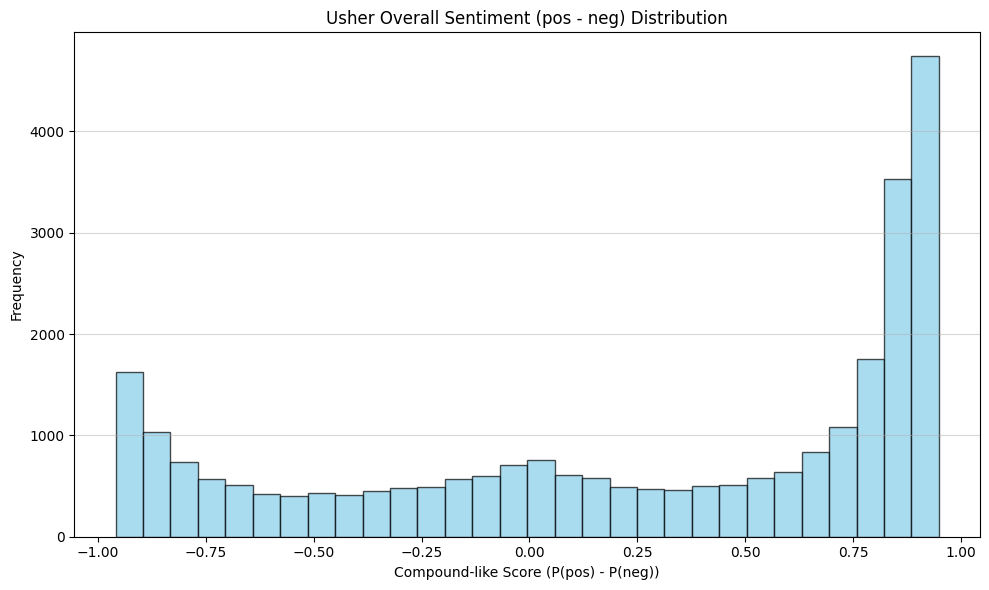

In [ ]:
# ===========================================
# Sentiment analysis with CardiffNLP XLM-R (multilingual)
# Model: cardiffnlp/twitter-xlm-roberta-base-sentiment
# Outputs: P(neg), P(neu), P(pos) + a compound-like score (pos - neg)
# ===========================================

# 1. FIXED: Removed 'torch' from here to avoid the dependency conflict error
!pip -q install -U transformers accelerate sentencepiece

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Check if 'df' exists; if not, create a dummy one for demonstration
if 'df' not in locals():
    print("No DataFrame found. Creating a dummy example...")
    df = pd.DataFrame({'text': ["I love this product!", "This is terrible.", "It is okay."]})

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

# CardiffNLP sentiment models are typically ordered: 0=negative, 1=neutral, 2=positive
IDX_NEG, IDX_NEU, IDX_POS = 0, 1, 2

def xlm_sentiment_batch(text_list, batch_size=64, max_length=128):
    """
    Returns a DataFrame with columns:
      sent_neg, sent_neu, sent_pos (probabilities)
      sent_compound = sent_pos - sent_neg  (range approx [-1, 1])
      sent_label = argmax class label
    """
    probs_all = []

    # Ensure strings
    text_list = ["" if t is None else str(t) for t in text_list]

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        # Tokenize
        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_all.append(probs)

    if len(probs_all) == 0:
         return pd.DataFrame()

    probs_all = np.vstack(probs_all)
    neg = probs_all[:, IDX_NEG]
    neu = probs_all[:, IDX_NEU]
    pos = probs_all[:, IDX_POS]

    # Calculate compound-like score
    compound = pos - neg

    labels_idx = probs_all.argmax(axis=1)
    idx2label = {IDX_NEG: "negative", IDX_NEU: "neutral", IDX_POS: "positive"}
    labels = [idx2label[i] for i in labels_idx]

    return pd.DataFrame({
        "sent_neg": neg,
        "sent_neu": neu,
        "sent_pos": pos,
        "sent_compound": compound,
        "sent_label": labels
    })

# --- Run sentiment on your dataframe ---
print("Running sentiment analysis...")
texts = df["text"].fillna("").astype(str).tolist()
sent_scores = xlm_sentiment_batch(texts, batch_size=64, max_length=128)

# Attach to df
# Reset index ensures alignment if original df had gaps
# FIX: Drop existing sentiment columns if they exist to avoid duplicates
cols_to_drop = [c for c in sent_scores.columns if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df = pd.concat([df.reset_index(drop=True), sent_scores.reset_index(drop=True)], axis=1)

# --- 2. FIXED: Overall sentiment summary ---
# Using simple column selection and mean() instead of .agg(name=(...))
cols_to_summarize = ["sent_compound", "sent_pos", "sent_neg", "sent_neu"]

# Calculate the mean for each selected column
mean_series = df[cols_to_summarize].mean().round(3)

# Create the sent_summary Series with custom index names
sent_summary = pd.Series({
    "avg_compound": mean_series["sent_compound"],
    "avg_pos": mean_series["sent_pos"],
    "avg_neg": mean_series["sent_neg"],
    "avg_neu": mean_series["sent_neu"]
})

print("=== Overall Sentiment Summary (XLM-R CardiffNLP) ===")
print(sent_summary, "\n")

# Label distribution
print("=== Sentiment Label Distribution ===")
print(df["sent_label"].value_counts(normalize=True).round(3), "\n")

# --- Histogram (compound-like) ---
plt.figure(figsize=(10, 6))
plt.hist(df["sent_compound"], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Usher Overall Sentiment (pos - neg) Distribution")
plt.xlabel("Compound-like Score (P(pos) - P(neg))")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

##Polished confidence-threshold method (XLM-R)


In [ ]:
import numpy as np
import pandas as pd

def add_confidence_threshold_labels(
    df: pd.DataFrame,
    prob_cols=("sent_pos", "sent_neu", "sent_neg"),
    compound_col="sent_compound",
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
) -> pd.DataFrame:
    df = df.copy()

    # confidence
    df["sent_conf"] = df[list(prob_cols)].max(axis=1)

    # argmax label -> FULL WORDS
    argmax_col = df[list(prob_cols)].idxmax(axis=1)
    mapping = {"sent_pos": "positive", "sent_neu": "neutral", "sent_neg": "negative"}
    df["sent_label_argmax"] = argmax_col.map(mapping)

    # start with argmax as default
    df["sent_label_polished"] = df["sent_label_argmax"]

    # apply confidence threshold
    df.loc[df["sent_conf"] < tau, "sent_label_polished"] = "neutral"

    # optionally apply a neutral band on compound for borderline polarity
    if use_both_rules:
        df.loc[df[compound_col].abs() < neutral_band, "sent_label_polished"] = "neutral"

    return df


# ---- Apply polishing ----
df = add_confidence_threshold_labels(
    df,
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
)

print("=== Label distribution (argmax) ===")
print(df["sent_label_argmax"].value_counts(normalize=True).round(3), "\n")

print("=== Label distribution (polished) ===")
print(df["sent_label_polished"].value_counts(normalize=True).round(3), "\n")

print("=== Confidence summary ===")
print(df["sent_conf"].describe().round(3))


=== Label distribution (argmax) ===
sent_label_argmax
positive    0.569
negative    0.265
neutral     0.165
Name: proportion, dtype: float64 

=== Label distribution (polished) ===
sent_label_polished
positive    0.496
neutral     0.303
negative    0.201
Name: proportion, dtype: float64 

=== Confidence summary ===
count    26982.000
mean         0.758
std          0.170
min          0.338
25%          0.616
50%          0.816
75%          0.908
max          0.971
Name: sent_conf, dtype: float64


##Best way to integrate with BERTopic (hedonic vs symbolic evidence-based)

In [ ]:
# ============================================================
# BERTopic × XLM-R Sentiment Integration (SAFE alignment)
# - Never truncates df to match doc_info
# - Runs sentiment on the SAME text list used by BERTopic: `docs`
# - Produces: doc_info_enriched, topic_summary_enriched (+ optional frame summary)
# ============================================================

import re
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# 0) Preconditions
# -----------------------------
# You must already have:
#   - topic_model: fitted BERTopic model
#   - docs: list of documents passed into BERTopic (same order)
if "topic_model" not in globals():
    raise NameError("❌ 'topic_model' not found. Run your BERTopic training cell first.")
if "docs" not in globals():
    raise NameError("❌ 'docs' not found. 'docs' must be the exact list used in BERTopic.fit_transform().")

# -----------------------------
# 1) Get per-document topic assignments (aligned to docs)
# -----------------------------
doc_info = topic_model.get_document_info(docs).copy()
doc_info = doc_info.reset_index(drop=True)

# -----------------------------
# 2) XLM-R sentiment on docs (guaranteed alignment)
# -----------------------------
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

IDX_NEG, IDX_NEU, IDX_POS = 0, 1, 2

def xlm_sentiment_batch(text_list, batch_size=64, max_length=128):
    probs_all = []
    text_list = ["" if t is None else str(t) for t in text_list]

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.append(probs)

    probs_all = np.vstack(probs_all) if probs_all else np.zeros((0, 3))
    neg, neu, pos = probs_all[:, IDX_NEG], probs_all[:, IDX_NEU], probs_all[:, IDX_POS]
    compound = pos - neg

    return pd.DataFrame({
        "sent_neg": neg,
        "sent_neu": neu,
        "sent_pos": pos,
        "sent_compound": compound
    })

def add_confidence_threshold_labels(
    df_scores: pd.DataFrame,
    prob_cols=("sent_pos", "sent_neu", "sent_neg"),
    compound_col="sent_compound",
    tau=0.60,
    neutral_band=0.15,
    use_both_rules=True
) -> pd.DataFrame:
    """
    Adds:
      - sent_conf: max class probability
      - sent_label_polished: {positive, neutral, negative}
    Rules:
      1) If sent_conf < tau -> neutral
      2) If use_both_rules and abs(compound) < neutral_band -> neutral
      Else -> argmax label
    """
    df_scores = df_scores.copy()

    df_scores["sent_conf"] = df_scores[list(prob_cols)].max(axis=1)

    argmax_col = df_scores[list(prob_cols)].idxmax(axis=1)
    mapping = {"sent_pos": "positive", "sent_neu": "neutral", "sent_neg": "negative"}
    df_scores["sent_label_polished"] = argmax_col.map(mapping)

    df_scores.loc[df_scores["sent_conf"] < tau, "sent_label_polished"] = "neutral"
    if use_both_rules:
        df_scores.loc[df_scores[compound_col].abs() < neutral_band, "sent_label_polished"] = "neutral"

    return df_scores

print("✅ Running XLM-R sentiment on docs (aligned to BERTopic)...")
sent_scores = xlm_sentiment_batch(docs, batch_size=64, max_length=128)
sent_scores = add_confidence_threshold_labels(sent_scores, tau=0.60, neutral_band=0.15, use_both_rules=True)

# Sanity check alignment
if len(sent_scores) != len(doc_info):
    raise ValueError(f"❌ Alignment error: len(sent_scores)={len(sent_scores)} vs len(doc_info)={len(doc_info)}")

# Attach sentiment to doc_info
required_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf", "sent_label_polished"]
doc_info_enriched = pd.concat(
    [doc_info, sent_scores[required_cols].reset_index(drop=True)],
    axis=1
)

# -----------------------------
# 3) Aggregate sentiment by Topic
# -----------------------------
EXCLUDE_OUTLIERS = False
doc_for_topics = doc_info_enriched if not EXCLUDE_OUTLIERS else doc_info_enriched[doc_info_enriched["Topic"] != -1].copy()

agg_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]
topic_sent_stats = doc_for_topics.groupby("Topic")[agg_cols].mean().reset_index()

topic_label_rates = (doc_for_topics.groupby("Topic")["sent_label_polished"]
    .agg(
        pct_positive=lambda s: (s == "positive").mean(),
        pct_negative=lambda s: (s == "negative").mean(),
        pct_neutral=lambda s: (s == "neutral").mean(),
    )
    .reset_index()
)

topic_summary_enriched = (topic_model.get_topic_info()
    .merge(topic_sent_stats, on="Topic", how="left")
    .merge(topic_label_rates, on="Topic", how="left")
)

print("✅ topic_summary_enriched created.")
print(topic_summary_enriched.head())

# -----------------------------
# 4) (Optional) Hedonic vs Symbolic evidence-based frame coding
#     - Uses Gemini labels if you have `labels` dict
#     - Otherwise uses topic top-words (TopicWords) for reproducible matching
# -----------------------------
HEDONIC_PAT = re.compile(
    r"\b(performance|show|music|song|setlist|vocals|voice|dance|choreo|stage|visuals|"
    r"sound|audio|mix|mic|camera|lighting|energy|hype|fun|entertaining|boring|"
    r"rewatch|watching again|best halftime|worst halftime|outstanding|nostalgia|hits)\b",
    flags=re.IGNORECASE
)

SYMBOLIC_PAT = re.compile(
    r"\b(message|meaning|politic|politics|representation|race|racist|identity|culture|"
    r"flag|protest|controversy|debate|snub|legacy|legend|beef|feud|diss|drake|lil wayne|"
    r"michael jackson|mj)\b",
    flags=re.IGNORECASE
)

def topic_words_as_text(topic_id: int, top_n=25) -> str:
    if topic_id == -1:
        return ""
    words = topic_model.get_topic(topic_id) or []
    return " ".join([w for w, _ in words[:top_n]])

def assign_frame(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "Other"
    hed = bool(HEDONIC_PAT.search(text))
    sym = bool(SYMBOLIC_PAT.search(text))
    if hed and sym:
        return "Hybrid"
    if hed:
        return "Hedonic"
    if sym:
        return "Symbolic"
    return "Other"

# Build frame label source
if "labels" in globals() and isinstance(labels, dict):
    topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
else:
    topic_summary_enriched["CustomName"] = np.nan

topic_summary_enriched["TopicWords"] = topic_summary_enriched["Topic"].apply(topic_words_as_text)
topic_summary_enriched["LabelForFrame"] = topic_summary_enriched["CustomName"].fillna(topic_summary_enriched["TopicWords"])

topic_summary_enriched["Frame"] = topic_summary_enriched["LabelForFrame"].apply(assign_frame)

print("\n=== Frame distribution (topics) ===")
print(topic_summary_enriched["Frame"].value_counts(dropna=False))

# Map Topic -> Frame back to documents
topic_to_frame = dict(zip(topic_summary_enriched["Topic"], topic_summary_enriched["Frame"]))
doc_info_enriched["Frame"] = doc_info_enriched["Topic"].map(topic_to_frame).fillna("Other")

frame_sent = (doc_info_enriched
    .groupby("Frame")
    .agg(
        n_docs=("Frame", "size"),
        mean_compound=("sent_compound", "mean"),
        pct_positive=("sent_label_polished", lambda s: (s == "positive").mean()),
        pct_negative=("sent_label_polished", lambda s: (s == "negative").mean()),
        pct_neutral=("sent_label_polished", lambda s: (s == "neutral").mean()),
        mean_conf=("sent_conf", "mean"),
    )
    .reset_index()
)

frame_sent[["mean_compound","pct_positive","pct_negative","pct_neutral","mean_conf"]] = \
    frame_sent[["mean_compound","pct_positive","pct_negative","pct_neutral","mean_conf"]].round(3)

print("\n=== Frame-level sentiment summary ===")
print(frame_sent.sort_values("n_docs", ascending=False))

# -----------------------------
# 5) (Optional) Export
# -----------------------------
# output_path = "bertopic_xlmr_topic_sentiment.xlsx"
# with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
#     topic_model.get_topic_info().to_excel(writer, sheet_name="Topic_Summary", index=False)
#     doc_info_enriched.to_excel(writer, sheet_name="Assignments+Sentiment", index=False)
#     topic_summary_enriched.to_excel(writer, sheet_name="Topic_Sentiment", index=False)
#     frame_sent.to_excel(writer, sheet_name="Frame_Summary", index=False)
# print(f"✅ Exported: {output_path}")


✅ Using device: cuda
✅ Running XLM-R sentiment on docs (aligned to BERTopic)...
✅ topic_summary_enriched created.
   Topic  Count                        Name  \
0      0  23960            0_the_was_and_to   
1      1   1854              1_de_que_el_la   
2      2   1168  2_alicia_keys_they_alicias   

                                          CustomName  \
0       Praise for Usher's halftime show performance   
1  Usher Super Bowl halftime show performance review   
2     Alicia Keys voice editing and pitch correction   

                                      Representation  \
0   [the, was, and, to, usher, this, is, of, it, he]   
1      [de, que, el, la, en, no, usher, los, un, es]   
2  [alicia, keys, they, alicias, note, voice, edi...   

                                 Representative_Docs  sent_compound  sent_pos  \
0  [ive watched this now for the fourth time the ...       0.136086  0.446633   
1  [usher rinde homenaje a michael jackson y the ...       0.093428  0.425166   
2  [

In [ ]:
# ============================
# EXPORT FULL RESULTS TO GOOGLE DRIVE (Excel)
# ============================
# 2) Choose output path
output_path = "/content/drive/MyDrive/Data/SBHT/usher_full_results.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 3) Excel row limit safety check (Excel hard limit = 1,048,576 rows per sheet)
EXCEL_MAX_ROWS = 1_048_576
too_big = len(doc_info_enriched) > EXCEL_MAX_ROWS

with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    # Topic-level summary + sentiment stats + frame assignment
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Summary", index=False)

    # Frame-level sentiment summary
    frame_sent.to_excel(writer, sheet_name="Frame_Sentiment", index=False)

    # Document-level assignments (can be huge)
    if not too_big:
        doc_info_enriched.to_excel(writer, sheet_name="Doc_Assignments", index=False)
    else:
        # If too big for Excel, write only the first chunk to Excel
        doc_info_enriched.head(EXCEL_MAX_ROWS).to_excel(writer, sheet_name="Doc_Assignments_Head", index=False)

print(f"✅ Exported Excel to: {output_path}")

# 4) If doc_info_enriched is too large for Excel, also export as CSV (recommended)
if too_big:
    csv_path = output_path.replace(".xlsx", "_Doc_Assignments.csv.gz")
    doc_info_enriched.to_csv(csv_path, index=False, compression="gzip")
    print(f"⚠️ doc_info_enriched has {len(doc_info_enriched):,} rows (exceeds Excel limit).")
    print(f"✅ Saved full Doc_Assignments as compressed CSV to: {csv_path}")


✅ Exported Excel to: /content/drive/MyDrive/Data/SBHT/usher_full_results.xlsx


In [ ]:
# -----------------------------
# 5) Export
# -----------------------------
# 1. Choose a Drive path
output_path = "/content/drive/MyDrive/Data/SBHT/usher_bertopic_xlmr_topic_sentiment.xlsx"

# 2. Create folders if they don't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 3. Build the tables you want to export (your variables assumed to exist)
topic_summary = topic_model.get_topic_info().copy()
topic_summary["CustomName"] = topic_summary["Topic"].map(labels)  # labels must be dict-like

doc_info = doc_info_enriched.copy()  # or: topic_model.get_document_info(docs).copy()
# doc_info["RawText"] = raw_docs     # if you have raw_docs

# 4. Write to Excel on Drive
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Sentiment", index=False)
    frame_sent.to_excel(writer, sheet_name="Frame_Summary", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/usher_bertopic_xlmr_topic_sentiment.xlsx


#Evidence-based “hedonic vs symbolic” coding (semi-automatic, reproducible)

In [ ]:
import re
import pandas as pd
import numpy as np

# ==========================================
# 0. Self-Correction: Ensure topic_summary_enriched exists (From Code B)
# ==========================================

# Define required_sent_cols unconditionally so it's always available
required_sent_cols = ["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf", "sent_label_polished"]

if 'topic_summary_enriched' not in globals():
    print("⚠️ 'topic_summary_enriched' not found. Attempting to reconstruct...")
    if 'topic_model' not in globals():
        raise NameError("Critical: 'topic_model' is not defined.")

    # Check for sentiment data
    has_df_sent = 'df' in globals() and all(c in df.columns for c in required_sent_cols)

    if has_df_sent:
        print("   Found sentiment data. Aggregating...")
        # Rebuild summary
        docs_source = docs if 'docs' in globals() else df['clean_text'].tolist()
        di = topic_model.get_document_info(docs_source).copy()

        # Attach sentiment
        df_reset = df.reset_index(drop=True)
        di = pd.concat([di.reset_index(drop=True), df_reset[required_sent_cols]], axis=1)

        # Aggregate
        stats = di.groupby("Topic")[["sent_compound", "sent_pos", "sent_neg", "sent_neu", "sent_conf"]].mean().reset_index()
        pos_pct = di.groupby("Topic")["sent_label_polished"].apply(lambda x: (x == "positive").mean()).reset_index(name="pct_positive")

        topic_summary_enriched = pd.merge(topic_model.get_topic_info(), stats, on="Topic", how="left")
        topic_summary_enriched = pd.merge(topic_model.get_topic_info(), pos_pct, on="Topic", how="left")
    else:
        topic_summary_enriched = topic_model.get_topic_info().copy()

# ==========================================
# 1. Define Patterns (EXPANDED from Code A)
# ==========================================
# Includes "Performance" domain
HEDONIC_PAT = re.compile(
    r"\b(performance|show|music|song|setlist|vocals|voice|dance|choreo|stage|visuals|"
    r"sound|audio|mix|mic|camera|lighting|energy|hype|fun|entertaining|boring|"
    r"rewatch|watching again|best halftime|worst halftime|outstanding|nostalgia|hits|"
    r"costume|outfit|dancer|skating|piano|guitar|band)\b", # Removed extra backslash here
    flags=re.IGNORECASE
)

# Includes "Sociopolitical" AND "Artist Comparison" domains
SYMBOLIC_PAT = re.compile(
    r"\b(message|meaning|politic|representation|race|racist|identity|culture|"
    r"palestine|sudan|flag|protest|controversy|debate|snub|legacy|legend|beef|feud|diss|"
    r"drake|lil wayne|kanye|mj|michael jackson|better than|worse than|goat|"
    r"king|rap god|lyricism|content|symbol|narrative|context)\b", # Removed extra backslash here
    flags=re.IGNORECASE
)

# ==========================================
# 2. Assignment Function
# ==========================================
def assign_frame(label: str) -> str:
    if not isinstance(label, str) or not label.strip():
        return "Other"

    # Check if 'CustomName' column exists, otherwise use label directly
    # (The apply function passes the string value)

    hed = bool(HEDONIC_PAT.search(str(label)))
    sym = bool(SYMBOLIC_PAT.search(str(label)))

    if hed and sym: return "Hybrid"
    if hed: return "Hedonic"
    if sym: return "Symbolic"
    return "Other"

# ==========================================
# 3. Apply to Summary
# ==========================================
# Ensure CustomName exists
if "CustomName" not in topic_summary_enriched.columns:
    if 'labels' in globals():
        topic_summary_enriched["CustomName"] = topic_summary_enriched["Topic"].map(labels)
    else:
        topic_summary_enriched["CustomName"] = topic_summary_enriched["Name"]

print("Classifying topics...")
topic_summary_enriched["Frame"] = topic_summary_enriched["CustomName"].apply(assign_frame)

print("\n=== Topic Frame Distribution ===")
print(topic_summary_enriched["Frame"].value_counts(dropna=False))

# ==========================================
# 4. Map Back to Documents & Calc Sentiment (From Code A)
# ==========================================
# Map Topic -> Frame
topic_to_frame = dict(zip(topic_summary_enriched["Topic"], topic_summary_enriched["Frame"]))

# Ensure 'Topic' exists in doc_info_enriched for mapping, which it should from BERTopic
# doc_info_enriched should contain sentiment columns from UrtOHpZDRo3B
if 'doc_info_enriched' not in globals() or not all(col in doc_info_enriched.columns for col in required_sent_cols):
    raise RuntimeError("doc_info_enriched is missing or does not contain required sentiment columns. Ensure previous sentiment analysis steps ran correctly.")

doc_info_enriched["Frame"] = doc_info_enriched["Topic"].map(topic_to_frame).fillna("Other")

# Aggregate Sentiment by Frame using the enriched doc_info_enriched
frame_sent = (doc_info_enriched
    .groupby("Frame")
    .agg(
        n_docs=("Frame", "size"),
        mean_compound=("sent_compound", "mean"),
        pct_pos=("sent_label_polished", lambda s: (s == "positive").mean()),
        pct_neg=("sent_label_polished", lambda s: (s == "negative").mean()),
        pct_neu=("sent_label_polished", lambda s: (s == "neutral").mean()),
        mean_conf=("sent_conf", "mean"),
    )
    .reset_index()
)

frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]] = \
    frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]].round(3)

print("\n=== Frame-Level Sentiment Summary ===")
print(frame_sent.sort_values("n_docs", ascending=False))

Classifying topics...

=== Topic Frame Distribution ===
Frame
Hedonic    3
Name: count, dtype: int64

=== Frame-Level Sentiment Summary ===
     Frame  n_docs  mean_compound  pct_pos  pct_neg  pct_neu  mean_conf
0  Hedonic   26982          0.123    0.393    0.211    0.396        0.7


In [ ]:
# ------------------------------------------------------------
# A) Ensure df has Topic via SAFE merge (doc_id), not row copy
# ------------------------------------------------------------

# 1) Build doc_info if not already present
if "doc_info" not in globals():
    # docs must be the same list used in BERTopic training/transform
    doc_info = topic_model.get_document_info(docs).copy()

# 2) Create stable doc_id in doc_info (if missing)
if "doc_id" not in doc_info.columns:
    doc_info = doc_info.reset_index(drop=True)
    doc_info["doc_id"] = range(len(doc_info))

# 3) Create stable doc_id in df (if missing)
if "doc_id" not in df.columns:
    df = df.reset_index(drop=True)
    df["doc_id"] = range(len(df))

# 4) Merge Topic into df if missing
if "Topic" not in df.columns:
    if len(df) != len(doc_info):
        raise ValueError(
            f"Cannot merge Topic safely: len(df)={len(df)} vs len(doc_info)={len(doc_info)}. "
            "You likely filtered df after creating docs. Rebuild df or docs with a consistent doc_id."
        )

    df = df.merge(
        doc_info[["doc_id", "Topic"]],
        on="doc_id",
        how="left",
        validate="one_to_one"
    )

# Sanity check
if df["Topic"].isna().any():
    raise ValueError("Some rows did not receive a Topic after merge. Check docs/df alignment.")

# ------------------------------------------------------------
# B) Map Topic -> Frame (robust typing)
# ------------------------------------------------------------
topic_to_frame = dict(
    zip(topic_summary_enriched["Topic"].astype(int), topic_summary_enriched["Frame"])
)

df["Frame"] = df["Topic"].astype(int).map(topic_to_frame).fillna("Other")

# ------------------------------------------------------------
# C) Frame-level sentiment summary
# ------------------------------------------------------------
frame_sent = (df
    .groupby("Frame", dropna=False)
    .agg(
        n_docs=("Frame", "size"),
        mean_compound=("sent_compound", "mean"),
        pct_pos=("sent_label_polished", lambda s: (s == "positive").mean()),
        pct_neg=("sent_label_polished", lambda s: (s == "negative").mean()),
        pct_neu=("sent_label_polished", lambda s: (s == "neutral").mean()),
        mean_conf=("sent_conf", "mean"),
    )
    .reset_index()
)

frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]] = \
    frame_sent[["mean_compound","pct_pos","pct_neg","pct_neu","mean_conf"]].round(3)

print(frame_sent.sort_values("n_docs", ascending=False))

     Frame  n_docs  mean_compound  pct_pos  pct_neg  pct_neu  mean_conf
0  Hedonic   26982          0.243    0.496    0.201    0.303      0.758


In [ ]:
import os

# 1. Define output_path (Missing variable)
output_path = "/content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_results2.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 2. Ensure topic_summary exists (in case it wasn't defined earlier)
if 'topic_summary' not in globals():
    topic_summary = topic_model.get_topic_info()

# 3. Export
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)

    # NEW:
    topic_summary_enriched.to_excel(writer, sheet_name="Topic_Sentiment", index=False)
    frame_sent.to_excel(writer, sheet_name="Frame_Summary", index=False)

print(f"✅ Exported to: {output_path}")

✅ Exported to: /content/drive/MyDrive/Data/SBHT/usher_bertopic_finetuned_results2.xlsx


# HEDONIC vs SYMBOLIC Frame Coding for BERTopic Topics (Gemini)

In [ ]:
# ============================================================
# HEDONIC vs SYMBOLIC Frame Coding for BERTopic Topics (Gemini)
# ============================================================
# Requirements:
#   pip install -U bertopic google-genai pandas tqdm
#
# Inputs you must have:
#   - topic_model: a trained BERTopic model
#   - docs: list[str] of documents used to train BERTopic (same order)
#
# Outputs:
#   - topic_frame_coding.csv
#   - topic_frame_coding.json
#
# Notes:
#   - Uses evidence bundles: top words + representative docs
#   - Repeats LLM classification for consensus + manual flags
# ============================================================

import os, re, json, time
from collections import Counter, defaultdict
import pandas as pd
from tqdm import tqdm

# Gemini SDK
from google import genai
from google.genai import types

In [ ]:
# ----------------------------
# 0) Gemini API setup
# ----------------------------
GOOGLE_API_KEY = userdata.get("Gemini_Key")
if not GOOGLE_API_KEY:
    raise ValueError("Missing Gemini_Key in Colab Secrets.")

client = genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_MODEL = "gemini-3-flash-preview"
GEMINI_SLEEP_SEC = 0.8  # increase if you see 429/rate-limit

In [ ]:
# ----------------------------
# 1) Operational definitions + JSON contract
# ----------------------------
SYSTEM_PROMPT = """
You are an expert framing-theory coder for social-media discourse about sport mega-events.

TASK:
Given a topic evidence bundle from BERTopic (keywords + representative comments),
classify the topic into exactly ONE generic frame:
- HEDONIC
- SYMBOLIC
- MANUAL_REVIEW (only if truly ambiguous)

FRAME DEFINITIONS (dominant evaluative lens):
HEDONIC = enjoyment/spectacle appraisal (performance quality, entertainment value, vibes, fun, aesthetics, hype, boring, goosebumps, showmanship).
SYMBOLIC = meaning/social interpretation (identity, culture, representation, morality, politics, controversy, ideology, social justice, message, disrespect, nationalism, protest).

DECISION RULES:
- Use ONLY the provided evidence bundle. Do NOT invent context.
- Decide based on the dominant lens across representative comments, not a single keyword.
- If mixed, choose the more central lens; if still unclear, use MANUAL_REVIEW.

OUTPUT REQUIREMENTS (MUST FOLLOW):
- Return STRICT JSON ONLY (no markdown, no extra text).
- Do NOT use placeholders like <int>, <float>, etc. Use real numbers.
- topic_id MUST be the integer from the input bundle.
- confidence MUST be a number in [0,1].
- Do NOT include newline characters in any string fields.
- Avoid double quotes inside strings; if needed, replace them with single quotes.

JSON SCHEMA:
{
  "topic_id": 0,
  "frame": "HEDONIC",
  "confidence": 0.85,
  "signals": {
    "keywords": ["word1","word2"],
    "comment_cues": ["short cue 1","short cue 2"]
  },
  "rationale": "<=60 words, grounded in the bundle"
}

EXAMPLE (format only):
{"topic_id":12,"frame":"SYMBOLIC","confidence":0.74,"signals":{"keywords":["identity","culture"],"comment_cues":["representation debate","political meaning"]},"rationale":"Comments emphasize representation and broader message rather than performance appraisal."}
""".strip()

JSON_REPAIR_SYSTEM = """
You are a JSON repair tool.
Given a string that is intended to be JSON, output ONLY a corrected STRICT JSON object.
Rules:
- Output ONLY JSON (no markdown, no commentary).
- Replace placeholders like <int> or <float> with valid values if needed.
- Ensure all strings are properly escaped and contain no raw newlines.
""".strip()

def _strip_code_fences(s: str) -> str:
    s = s.strip()
    if s.startswith("```"):
        s = re.sub(r"^```[a-zA-Z0-9]*\n", "", s)
        s = re.sub(r"\n```$", "", s)
    return s.strip()

def _extract_first_json_object(s: str) -> str:
    s = _strip_code_fences(s)
    # normalize smart quotes
    s = s.replace("“", '"').replace("”", '"').replace("’", "'")
    start = s.find("{")
    end = s.rfind("}")
    if start == -1 or end == -1 or end <= start:
        return s
    return s[start:end+1]

def gemini_repair_json(bad_json_text: str, max_output_tokens: int = 512) -> str:
    cfg = types.GenerateContentConfig(
        system_instruction=JSON_REPAIR_SYSTEM,
        temperature=0.0,
        max_output_tokens=max_output_tokens,
        response_mime_type="application/json",
    )
    resp = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=bad_json_text,
        config=cfg
    )
    return (resp.text or "").strip()

def _clean_text(s: str, max_chars: int = 280) -> str:
    """Clean and truncate to keep prompts compact."""
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s[:max_chars]


def build_topic_bundle(topic_model, topic_id: int, top_n_words: int = 12, n_docs: int = 8):
    """Create the evidence bundle Gemini will see."""
    # Keywords from BERTopic
    kw_pairs = topic_model.get_topic(topic_id) or []
    keywords = [w for w, _ in kw_pairs[:top_n_words]]

    # Representative docs (BERTopic stores these)
    rep_docs = []
    try:
        rep_docs = topic_model.get_representative_docs(topic_id) or []
    except Exception:
        rep_docs = []

    rep_docs = [_clean_text(d) for d in rep_docs[:n_docs]]

    bundle = {
        "topic_id": int(topic_id),
        "keywords": keywords,
        "representative_comments": rep_docs
    }
    return bundle


def gemini_classify_topic(bundle: dict,
                          temperature: float = 0.0,
                          max_output_tokens: int = 384,
                          retry: int = 2,
                          sleep_s: float = 0.8) -> dict:
    user_prompt = json.dumps(bundle, ensure_ascii=False)

    config = types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPT,
        temperature=temperature,
        max_output_tokens=max_output_tokens,
        response_mime_type="application/json",
    )

    last_err = None

    for attempt in range(retry + 1):
        try:
            resp = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=user_prompt,
                config=config
            )

            raw = (resp.text or "").strip()
            if not raw:
                raise ValueError("Empty Gemini response.")

            raw_json = _extract_first_json_object(raw)

            # 1) direct parse
            try:
                data = json.loads(raw_json)
            except json.JSONDecodeError:
                # 2) repair pass
                repaired = gemini_repair_json(raw_json)
                repaired_json = _extract_first_json_object(repaired)
                data = json.loads(repaired_json)

            # minimal validation + enforce topic_id
            if "topic_id" not in data or "frame" not in data:
                raise ValueError(f"Invalid JSON keys: {data}")

            data["topic_id"] = int(bundle["topic_id"])  # enforce correct id

            # ensure confidence is numeric
            try:
                data["confidence"] = float(data.get("confidence", 0.0))
            except Exception:
                data["confidence"] = 0.0

            return data

        except Exception as e:
            last_err = e
            time.sleep(sleep_s)

    # IMPORTANT: don't crash the entire run
    return {
        "topic_id": int(bundle["topic_id"]),
        "frame": "MANUAL_REVIEW",
        "confidence": 0.0,
        "signals": {"keywords": bundle.get("keywords", [])[:12], "comment_cues": []},
        "rationale": f"LLM JSON parsing failed after retries/repair. Last error: {str(last_err)[:120]}"
    }


def consensus_vote(run_outputs: list,
                   agree_threshold: float = 0.67) -> dict:
    """
    Majority vote across repeated Gemini runs.
    If consensus < threshold, set frame to MANUAL_REVIEW.
    """
    frames = [o.get("frame") for o in run_outputs if isinstance(o, dict)]
    counts = Counter(frames)
    if not counts:
        return {
            "final_frame": "MANUAL_REVIEW",
            "consensus": 0.0,
            "frame_counts": {},
            "final_confidence": 0.0
        }

    top_frame, top_n = counts.most_common(1)[0]
    consensus = top_n / len(frames)

    # Compute average confidence among runs that chose the top frame
    confs = [float(o.get("confidence", 0.0)) for o in run_outputs if o.get("frame") == top_frame]
    avg_conf = sum(confs) / len(confs) if confs else 0.0

    if consensus < agree_threshold:
        return {
            "final_frame": "MANUAL_REVIEW",
            "consensus": consensus,
            "frame_counts": dict(counts),
            "final_confidence": avg_conf
        }

    return {
        "final_frame": top_frame,
        "consensus": consensus,
        "frame_counts": dict(counts),
        "final_confidence": avg_conf
    }


def classify_all_topics(topic_model,
                        top_n_words: int = 12,
                        n_docs: int = 8,
                        n_runs: int = 3,
                        agree_threshold: float = 0.67,
                        temperature: float = 0.2,
                        rate_limit_sleep_s: float = 0.25,
                        exclude_outlier_topic: bool = True):
    """
    Iterate through BERTopic topics and classify each into Hedonic/Symbolic.
    """
    info = topic_model.get_topic_info()
    topic_ids = info["Topic"].tolist()

    if exclude_outlier_topic and (-1 in topic_ids):
        topic_ids = [t for t in topic_ids if t != -1]

    results = []
    for tid in tqdm(topic_ids, desc="Classifying topics"):
        bundle = build_topic_bundle(topic_model, tid, top_n_words=top_n_words, n_docs=n_docs)

        run_outputs = []
        for r in range(n_runs):
            out = gemini_classify_topic(bundle, temperature=temperature)
            run_outputs.append(out)
            time.sleep(rate_limit_sleep_s)

        vote = consensus_vote(run_outputs, agree_threshold=agree_threshold)

        # Keep a compact “signals”/rationale snapshot from first run (you can also keep all)
        first = run_outputs[0]
        row = {
            "topic_id": tid,
            "final_frame": vote["final_frame"],
            "consensus": vote["consensus"],
            "final_confidence": vote["final_confidence"],
            "frame_counts": json.dumps(vote["frame_counts"], ensure_ascii=False),

            # Evidence bundle (good for audit trail / appendix)
            "keywords": json.dumps(bundle["keywords"], ensure_ascii=False),
            "rep_comments": json.dumps(bundle["representative_comments"], ensure_ascii=False),

            "example_rationale": first.get("rationale", ""),
            "example_comment_cues": json.dumps(first.get("signals", {}).get("comment_cues", []), ensure_ascii=False),
        }
        results.append(row)

    df = pd.DataFrame(results)
    return df

In [ ]:
# ----------------------------
# 2) Run it (you provide topic_model)
# ----------------------------
df_frames = classify_all_topics(topic_model,
                                top_n_words=12,
                                n_docs=8,
                                n_runs=3,
                                agree_threshold=0.67,
                                temperature=0.2)

Classifying topics: 100%|██████████| 3/3 [02:38<00:00, 52.90s/it]


In [ ]:
# ============================
# Export (Topic frames + assignments) to Excel
# ============================

output_path = "/content/drive/MyDrive/Data/SBHT/usher_topic_frames_Gemini.xlsx"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# --- A) Topic summary from BERTopic ---
topic_summary = topic_model.get_topic_info().copy()

# Optional: if you already have custom topic labels from a dict like {topic_id: "label"}
# labels = {...}
if "labels" in globals() and isinstance(labels, dict):
    topic_summary["CustomName"] = topic_summary["Topic"].map(labels)
else:
    topic_summary["CustomName"] = ""

# --- B) Add Gemini frame classification results (df_frames) ---
# df_frames should include: topic_id, final_frame, consensus, final_confidence, frame_counts, keywords, rep_comments, etc.
# Ensure consistent key name for merging
df_merge = df_frames.copy()
df_merge["Topic"] = df_merge["topic_id"].astype(int)

topic_summary = topic_summary.merge(
    df_merge.drop(columns=["topic_id"], errors="ignore"),
    on="Topic",
    how="left"
)

# --- C) Document-level assignments (topic + frame per comment) ---
doc_info = topic_model.get_document_info(docs).copy()

# Optional raw text column (recommended)
# raw_docs = [...]
if "raw_docs" in globals() and raw_docs is not None and len(raw_docs) == len(doc_info):
    doc_info["RawText"] = raw_docs

# Map topic -> final_frame onto documents
topic_to_frame = dict(zip(df_frames["topic_id"].astype(int), df_frames["final_frame"]))
doc_info["final_frame"] = doc_info["Topic"].astype(int).map(topic_to_frame).fillna("OUTLIER_OR_UNKNOWN")

# ============================
# Write to Excel (multiple sheets)
# ============================
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    topic_summary.to_excel(writer, sheet_name="Topic_Summary", index=False)
    df_frames.to_excel(writer, sheet_name="Frame_Coding", index=False)     # full audit table
    doc_info.to_excel(writer, sheet_name="Assignments", index=False)       # doc-topic-frame mapping

print(f"✅ Exported to: {output_path}")


✅ Exported to: /content/drive/MyDrive/Data/SBHT/usher_topic_frames_Gemini.xlsx
